# Vitesse moyenne — passif / actif sans mémoire / actif avec mémoire

**Mode d'emploi**

- La cellule **Setup** (juste en dessous) est à lancer une fois : imports, chemins, paramètres communs et fonctions utilitaires.
- Ensuite, **chaque cellule est indépendante** : elle recharge ses données via les fonctions du Setup (mise en cache, donc pas de relecture des parquet) et définit ses propres paramètres locaux. Aucune cellule ne dépend d'une variable créée par une autre → on peut les lancer dans n'importe quel ordre.
- Les réplicats sont moyennés une seule fois, dans `load_fact`, en groupant **uniquement** sur les paramètres `COLUMNS`.
- Un **gain** est toujours `G = valeur(cas étudié) / valeur(cas de référence)`, calculé **à paramètres identiques** par jointure sur `COLUMNS` (voir `compute_gain`).

# Setup

In [1]:
# - Librairies -----
import warnings
from functools import lru_cache

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from nucleo.io.reading import reading_all_parquet

warnings.filterwarnings("ignore", message=".*Resolving the schema of a LazyFrame.*")


# - Chemins des données -----
OUTPUTS = "/home/nicolas/Documents/Workspace/nucleo/outputs"

ROOT_PASSIVE = f"{OUTPUTS}/FACT__PSMN__2026"                # passfull
# ROOT_PASSIVE = f"{OUTPUTS}/FACT__PSMN__2026-05-21"
# ROOT_PASSIVE = f"{OUTPUTS}/FACT__PSMN__2026-09-17"
ROOT_ACTIVE  = f"{OUTPUTS}/FACT__PSMN__2026-09-26"          # actifull + actimemo

# # Run unique utilisé pour la vérification (section "Actif avec mémoire")
# ROOT_VERIF = (
#     f"{OUTPUTS}/FACT_ACTIVE_MEMORY__PC__2026-09-22/nucleo__actimemo__0/"
#     "algo=2S__fact=True__mode=actimemo__dstr=False__land=periodic__s=35__l=10__bpmin=0__mu=150__theta=100"
#     "__rcapt=2.0e+00__rrest=1.0e-01__alphac=6.7e-01__alphad=0.0e+00__alphar=0.0e+00__krel=1.0e+00"
#     "__Kp=6.0e-01__Kz=0.0e+00__nt=1.0e+01__"
# )


# - Paramètres retenus pour toutes les comparaisons -----
MU, THETA, RREST = 150, 100, 2.0
S, ALPHAC        = 35, 0.67

KZ_PASSIVE    = 0.0      # Kz retenu pour le passif
ALPHAR_ACTIVE = 1.0      # alphar retenu pour les cas actifs
KZ_GEQ_KP     = True     # cas actifs : on ne garde que Kz >= Kp

LANDS = ["periodic", "random"]

# Colonnes qui définissent une condition de simulation (tout le reste = résultats)
COLUMNS = [
    'algo', 'fact', 'mode', 'dstr',
    'land', 's', 'l', 'bpmin',
    'mu', 'theta', 'alphaf',
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad',
    'alphar', 'krel', 'Kp', 'Kz'
]

# - Style des figures -----
TOL     = 1e-6           # tolérance pour comparer des floats
FIGSIZE = (8, 6)
DPI     = 300


# ─────────────────────────────────────────────────────────────────────────────
# Chargement
# ─────────────────────────────────────────────────────────────────────────────
@lru_cache(maxsize=None)
def load_fact(root):
    """Lit tous les parquet de `root` et moyenne les réplicats (mêmes COLUMNS)."""
    df = reading_all_parquet(root)
    value_cols = [
        c for c in df.columns
        if c not in COLUMNS and df.schema[c].is_numeric()
    ]
    return (
        df.group_by(COLUMNS)
        .agg([pl.col(c).mean() for c in value_cols])
        .sort(COLUMNS)
    )


def sel(df, **conds):
    """Filtre df sur colonne == valeur (tolérance TOL pour les floats)."""
    exprs = [
        (pl.col(k) - v).abs() < TOL if isinstance(v, float) else pl.col(k) == v
        for k, v in conds.items()
    ]
    return df.filter(pl.all_horizontal(exprs)) if exprs else df


def load_passive(filtered=True):
    """Passif (passfull). filtered=True : mu, theta, rrest, Kz fixés (cf. paramètres)."""
    df = load_fact(ROOT_PASSIVE).filter(pl.col("mode") == "passfull")
    if filtered:
        df = sel(df, mu=MU, theta=THETA, rrest=RREST, Kz=KZ_PASSIVE)
    return df.with_columns((pl.col("Kp") * pl.col("alphar")).alias("Kpalphar"))


def load_actifull(filtered=True):
    """Actif sans mémoire (actifull). filtered=True : mu, theta, rrest fixés."""
    df = load_fact(ROOT_ACTIVE).filter(
        (pl.col("mode") == "actifull") & pl.col("land").is_in(LANDS)
    )
    if filtered:
        df = sel(df, mu=MU, theta=THETA, rrest=RREST, alphar=ALPHAR_ACTIVE)
    return df


def load_actimemo(filtered=True):
    """Actif avec mémoire (actimemo). filtered=True : mu, theta, rrest, alphar fixés."""
    df = load_fact(ROOT_ACTIVE).filter(pl.col("mode") == "actimemo")
    if filtered:
        df = sel(df, mu=MU, theta=THETA, rrest=RREST, alphar=ALPHAR_ACTIVE)
    return df


def describe_params(df):
    """Affiche les valeurs uniques de chaque paramètre."""
    print(df.shape)
    for col in COLUMNS:
        print(f"{col:7s}: {np.unique(df[col].to_numpy())}")


def keep_kz_ge_kp(df):
    """Cas actifs : ne garde que Kz >= Kp (désactivable avec KZ_GEQ_KP)."""
    return df.filter(pl.col("Kz") >= pl.col("Kp") - TOL) if KZ_GEQ_KP else df


# ─────────────────────────────────────────────────────────────────────────────
# Gains à paramètres identiques
# ─────────────────────────────────────────────────────────────────────────────
def _round_keys(df, decimals=6):
    """Arrondit les paramètres float pour que la jointure ne rate pas sur 1e-16."""
    floats = [
        c for c in COLUMNS
        if c in df.columns and df.schema[c] in (pl.Float32, pl.Float64)
    ]
    return df.with_columns([pl.col(c).round(decimals) for c in floats])


def compute_gain(df_num, df_ref, value="v_mean", value_ref=None, ref_factor=None,
                 exclude=(), average_ref_over=()):
    """
    Gain G = value(df_num) / value_ref(df_ref), à paramètres identiques.

    La jointure se fait sur tous les paramètres de COLUMNS (sauf `mode`), sauf :
      - exclude          : paramètres NON joints (ex. un paramètre propre à un seul cas).
                           On garde la valeur de df_num, et celle de df_ref
                           avec le suffixe `_ref` (ex. krel -> krel_ref).
      - average_ref_over : paramètres de df_ref sur lesquels on MOYENNE la référence
                           (ex. baseline sans remodelage : alphar = 0, quel que soit Kp).
                           Ils restent disponibles côté df_num.
    Options :
      - value_ref  : colonne de la référence si différente de `value`
      - ref_factor : expression polars multipliant la référence (ex. facteur c)

    Retour : DataFrame avec les paramètres, `v_num`, `v_ref` et `gain`.
    """
    value_ref = value_ref or value
    excl, avg = list(exclude), list(average_ref_over)
    keys = [c for c in COLUMNS if c != "mode" and c not in excl + avg]

    num = (
        _round_keys(df_num)
        .select(keys + excl + avg + [value])
        .rename({value: "v_num"})
    )

    ref = _round_keys(df_ref).select(keys + excl + [value_ref])
    if avg:
        ref = ref.group_by(keys + excl).agg(pl.col(value_ref).mean())
    ref = ref.rename({value_ref: "v_ref", **{c: f"{c}_ref" for c in excl}})

    g = num.join(ref, on=keys, how="inner")
    if g.is_empty():
        print("⚠ Aucun jeu de paramètres commun entre les deux cas (cf. report_overlap).")
        return g.with_columns(pl.lit(None, dtype=pl.Float64).alias("gain"))

    if ref_factor is not None:
        g = g.with_columns(pl.col("v_ref") * ref_factor)

    return g.with_columns((pl.col("v_num") / pl.col("v_ref")).alias("gain")).sort(keys + excl + avg)


def report_overlap(df_num, df_ref, exclude=()):
    """Affiche les paramètres dont les valeurs diffèrent entre les deux cas."""
    r = lambda x: round(x, 6) if isinstance(x, float) else x
    for c in COLUMNS:
        if c == "mode":
            continue
        a = {r(x) for x in df_num[c].unique().to_list()}
        b = {r(x) for x in df_ref[c].unique().to_list()}
        if a != b or c in exclude:
            tag = " (non joint)" if c in exclude else ""
            print(f"{c:7s}{tag}: cas étudié={sorted(a)} | référence={sorted(b)} | communs={sorted(a & b)}")


def interpolate_along(df, along, targets, value_cols):
    """
    Ajoute à `df` des lignes où le paramètre `along` vaut chaque valeur de `targets`
    (dans l'intervalle de la grille), avec `value_cols` interpolées linéairement.
    Ne renvoie que COLUMNS + value_cols (les autres colonnes n'auraient plus de sens).
    """
    base = df.select(COLUMNS + list(value_cols))
    others = [c for c in COLUMNS if c != along]
    rows = []
    for part in base.partition_by(others, maintain_order=True):
        x = part[along].to_numpy()
        order = np.argsort(x)
        x = x[order]
        for t in targets:
            if x[0] < t < x[-1] and not np.isclose(x, t, atol=TOL).any():
                rows.append(
                    part.head(1).with_columns(
                        pl.lit(float(t)).alias(along),
                        *[
                            pl.lit(float(np.interp(t, x, part[v].to_numpy()[order]))).alias(v)
                            for v in value_cols
                        ],
                    )
                )
    return pl.concat([base, *rows]) if rows else base


# ─────────────────────────────────────────────────────────────────────────────
# Tracés
# ─────────────────────────────────────────────────────────────────────────────
def iter_curves(df):
    """Un (l, land, sous-tableau) par courbe, dans l'ordre l puis land."""
    for l in sorted(df["l"].unique().to_list()):
        for land in LANDS:
            sub = df.filter((pl.col("l") == l) & (pl.col("land") == land))
            if not sub.is_empty():
                yield l, land, sub


MARKERS = {"random": "o", "periodic": "s"}


def plot_curves(df, x, y, xlabel, ylabel, title=None, hline=None,
                xticks=None, yticks=None, ylim=None, legend_loc="best"):
    """Une figure, une courbe y(x) par (l, land)."""
    if df.is_empty():
        return
    plt.figure(figsize=FIGSIZE, dpi=DPI)
    for l, land, sub in iter_curves(df):
        sub = sub.sort(x)
        plt.plot(
            sub[x].to_numpy(), sub[y].to_numpy(),
            marker=MARKERS.get(land, "o"), alpha=0.70, label=f"land={land} | $l={l}$",
        )
    if hline is not None:
        plt.axhline(hline, color="grey", ls="--", lw=1)
    if title:
        plt.title(title)
    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    if ylim is not None:
        plt.ylim(ylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.30)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()

# Passif

## Aperçu des données

In [2]:
# - Données brutes (avant filtrage) -----
df_passive_all = load_passive(filtered=False)
print(df_passive_all)

describe_params(df_passive_all)

shape: (13_068, 62)
┌──────┬──────┬──────────┬───────┬───┬──────────┬──────────┬───────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dt_mean  ┆ dt_med   ┆ dt_mp ┆ Kpalphar │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---   ┆ ---      │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64      ┆ f64      ┆ f64   ┆ f64      │
╞══════╪══════╪══════════╪═══════╪═══╪══════════╪══════════╪═══════╪══════════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 9.596044 ┆ 6.892134 ┆ 1.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 9.539754 ┆ 6.817726 ┆ 1.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 9.428299 ┆ 6.781026 ┆ 1.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 9.517103 ┆ 6.788672 ┆ 1.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 9.40595  ┆ 6.774479 ┆ 1.5   ┆ 0.0      │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …        ┆ …        ┆ …     ┆ …        │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.998314 ┆ 0.838127 ┆ 0.5   ┆ 0.9      │
│ 2S   ┆ true ┆ pass

## $v_{\mathrm{mean}}$ aux bornes : $\alpha_r$ ou $K_p$ fixé à 0 puis à 1

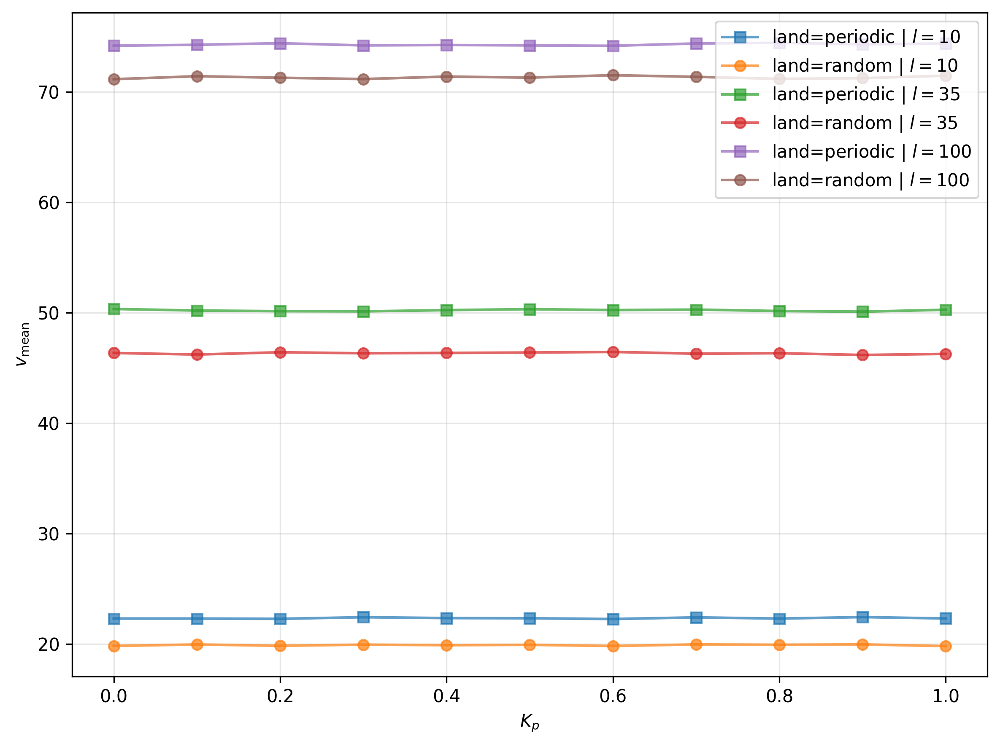

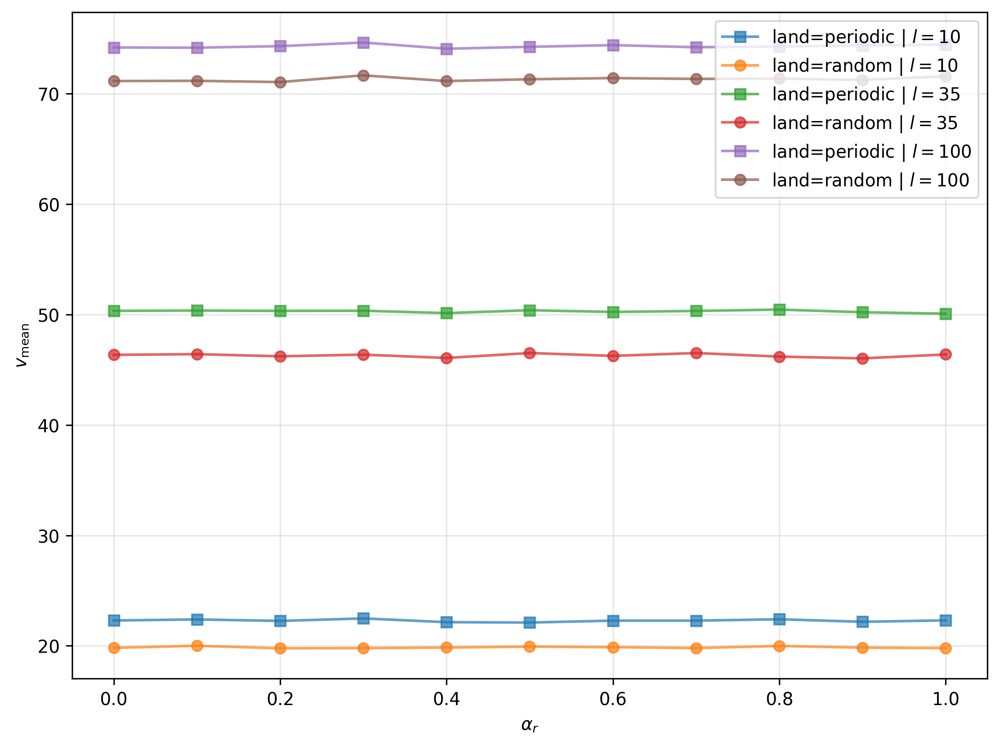

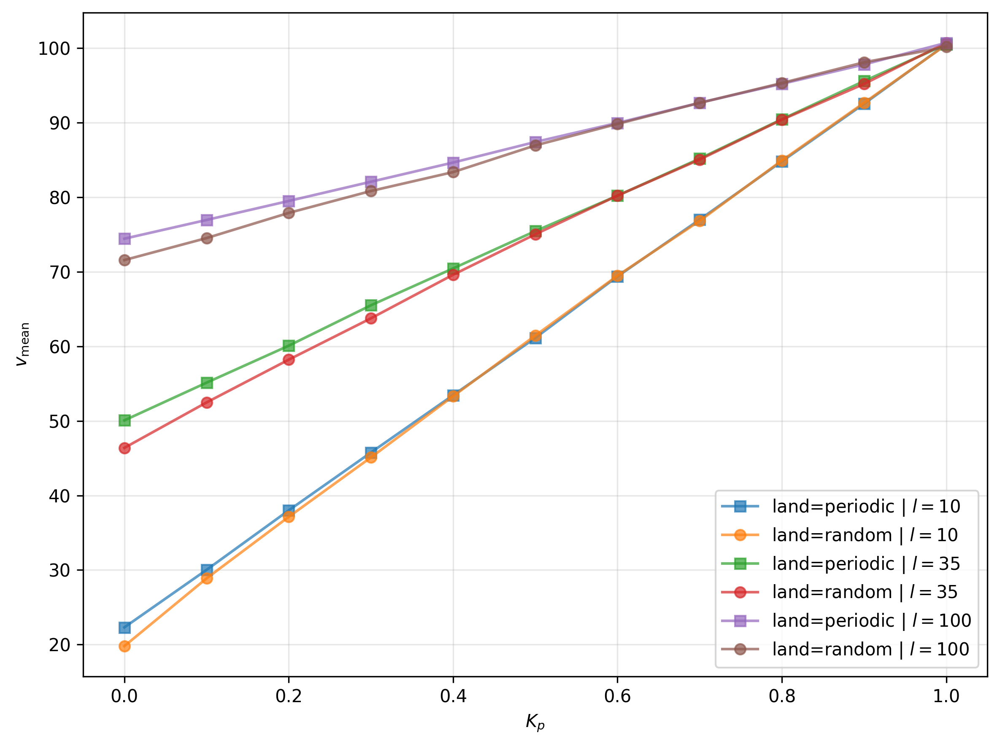

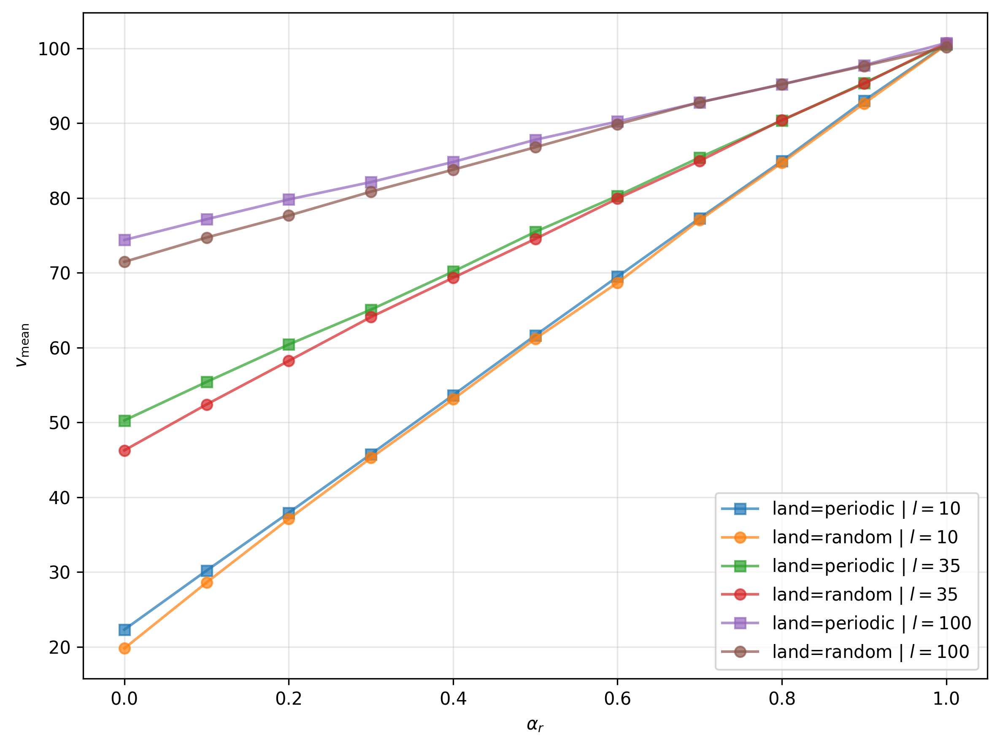

In [3]:
# - Paramètres -----
V_COL  = "v_mean"
FIXED  = (0.0, 1.0)      # valeurs de alphar / Kp maintenues constantes

# - Données -----
df = load_passive()

# - Plots -----
for fixed in FIXED:

    # v_mean en fonction de Kp, alphar fixé
    plot_curves(
        sel(df, alphar=fixed), x="Kp", y=V_COL,
        xlabel=r"$K_p$", ylabel=r"$v_{\mathrm{mean}}$",
        # title=rf"$\alpha_r = {fixed:g}$",
    )

    # v_mean en fonction de alphar, Kp fixé
    plot_curves(
        sel(df, Kp=fixed), x="alphar", y=V_COL,
        xlabel=r"$\alpha_r$", ylabel=r"$v_{\mathrm{mean}}$",
        # title=rf"$K_p = {fixed:g}$",
    )

## $v_{\mathrm{mean}}$ en fonction de $K_p \, \alpha_r$

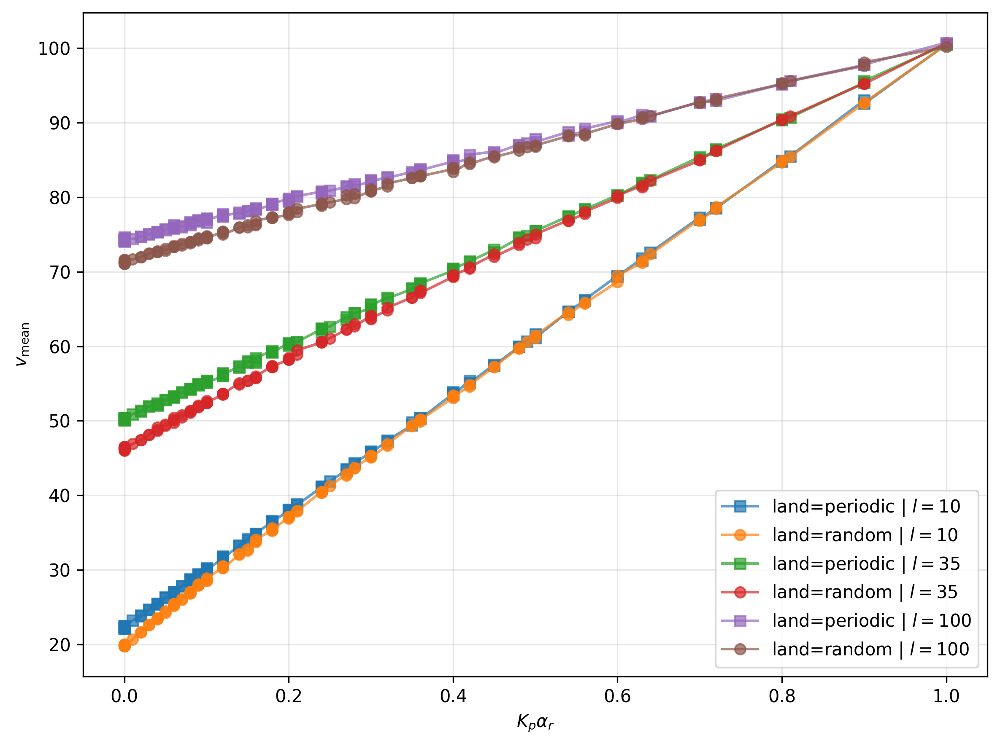

In [4]:
# - Données -----
df = load_passive()          # contient déjà la colonne Kpalphar = Kp * alphar

# - Plot -----
plot_curves(
    df, x="Kpalphar", y="v_mean",
    xlabel=r"$K_p \alpha_r$", ylabel=r"$v_{\mathrm{mean}}$",
)

## Valeurs théoriques de référence ($v_{\mathrm{mean}}$)

In [5]:
# - Calcul à la main (issu du notebook d'origine : 150 * (10/45) * 0.67) -----
L_VALUES = (10, 35, 100)

for l in L_VALUES:
    v_th = MU * l / (S + l) * ALPHAC
    print(f"l = {l:3d} | mu * l/(s+l) * alphac = {v_th:.2f}")

l =  10 | mu * l/(s+l) * alphac = 22.33
l =  35 | mu * l/(s+l) * alphac = 50.25
l = 100 | mu * l/(s+l) * alphac = 74.44


# Passif : bp

## $v_{c,\mathrm{mean}}$ en fonction de $K_p \, \alpha_r$

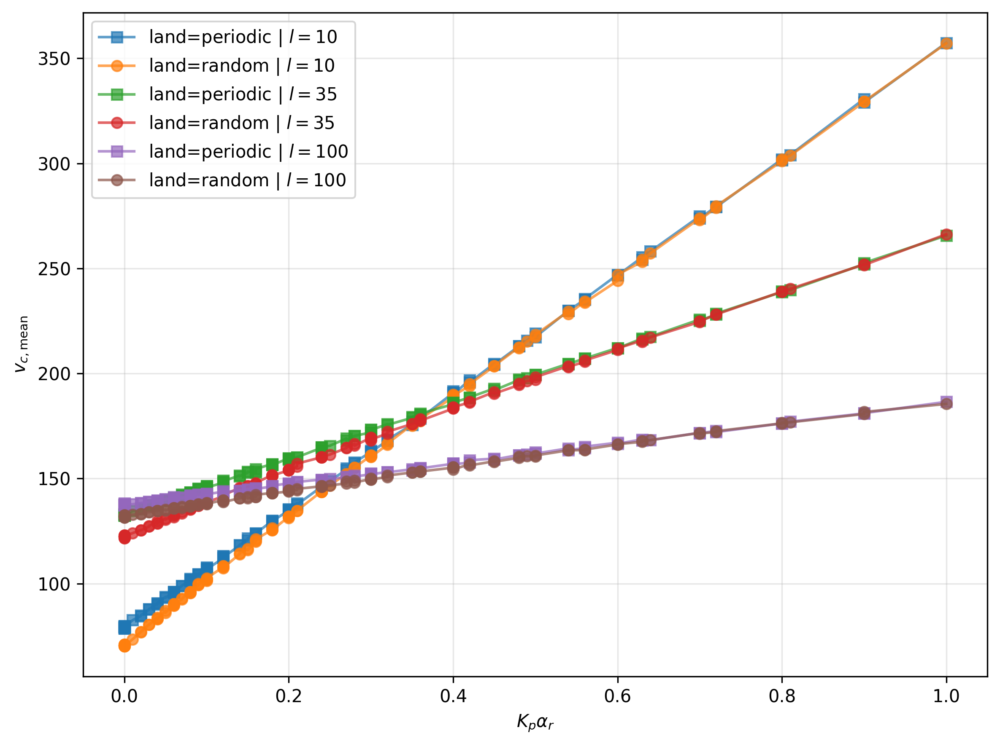

In [6]:
# - Données -----
df = load_passive()

# - Plot -----
plot_curves(
    df, x="Kpalphar", y="vc_mean",
    xlabel=r"$K_p \alpha_r$", ylabel=r"$v_{c,\mathrm{mean}}$",
)

# --------------------------------------------------------------------------------------------------------------------------------------------

## Valeurs théoriques de référence ($v_{c,\mathrm{mean}}$)

In [7]:
# - Calcul à la main (issu du notebook d'origine : 150 * 160/45 * 0.67) -----
L_VALUES = (10, 35, 100)

for l in L_VALUES:
    c    = (MU + l) / (S + l)          # facteur bp
    v_th = MU * c * ALPHAC
    print(f"l = {l:3d} | c = (mu+l)/(s+l) = {c:.3f} | mu * c * alphac = {v_th:.2f}")

l =  10 | c = (mu+l)/(s+l) = 3.556 | mu * c * alphac = 357.33
l =  35 | c = (mu+l)/(s+l) = 2.643 | mu * c * alphac = 265.61
l = 100 | c = (mu+l)/(s+l) = 1.852 | mu * c * alphac = 186.11


# Actif sans mémoire

## Aperçu des données

In [8]:
# - Données brutes (avant filtrage) -----
df_actifull_all = load_actifull(filtered=True)

describe_params(df_actifull_all)

(792, 61)
algo   : ['2S']
fact   : [ True]
mode   : ['actifull']
dstr   : [False]
land   : ['periodic' 'random']
s      : [35]
l      : [ 10  35 100]
bpmin  : [0]
mu     : [150]
theta  : [100]
alphaf : [1.]
alphao : [0.]
beta   : [0.]
rcapt  : [2.]
rrest  : [2.]
alphac : [0.67]
alphad : [0.]
alphar : [1.]
krel   : [ 0.1         0.46415888  2.15443469 10.        ]
Kp     : [0.1        0.17782794 0.31622777]
Kz     : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## $v_{c,\mathrm{mean}}$ en fonction de $K_z$

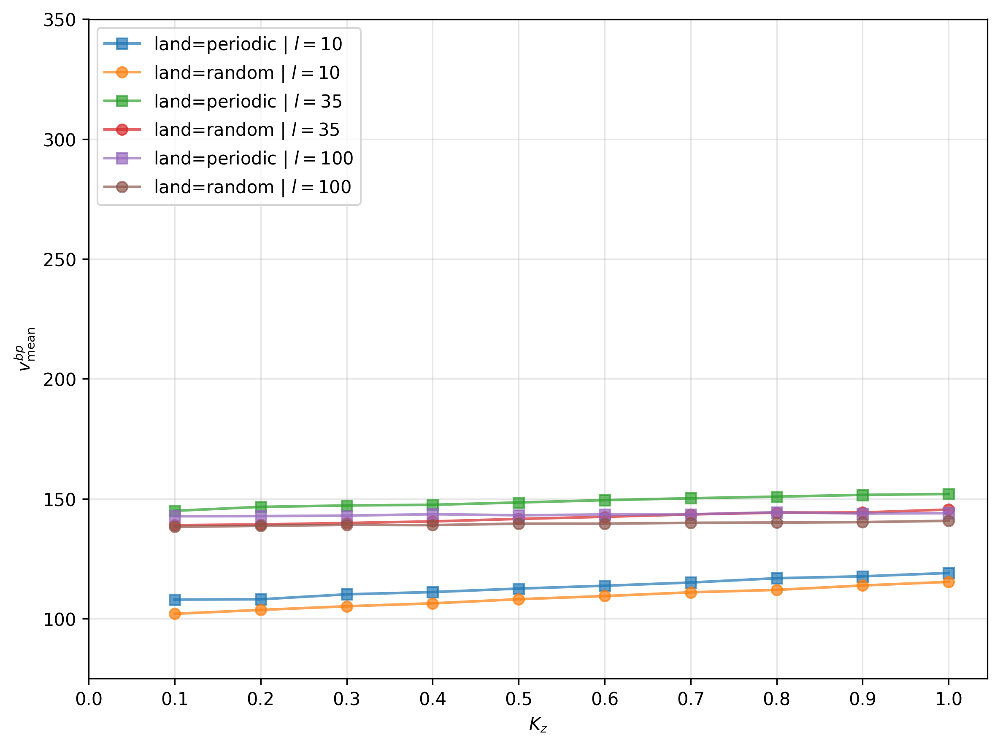

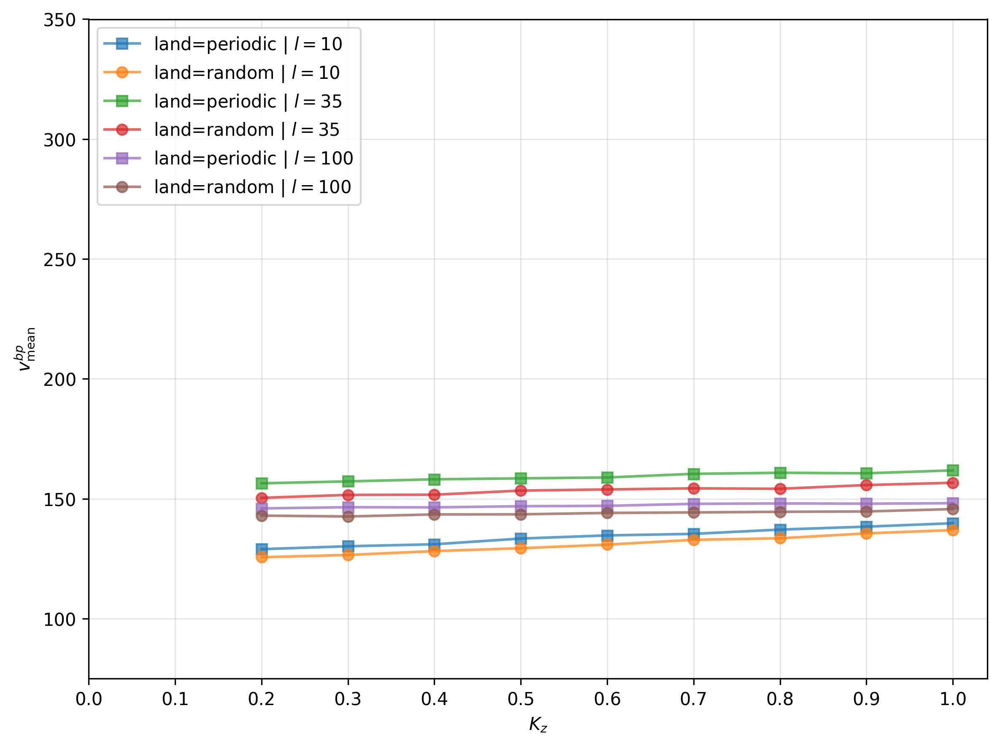

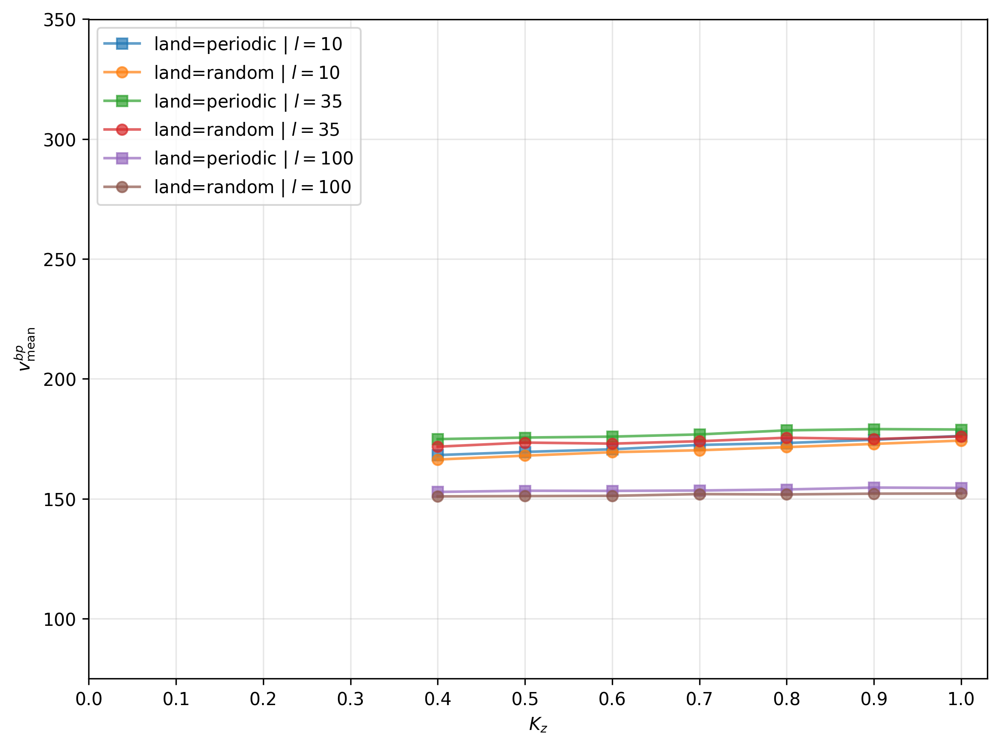

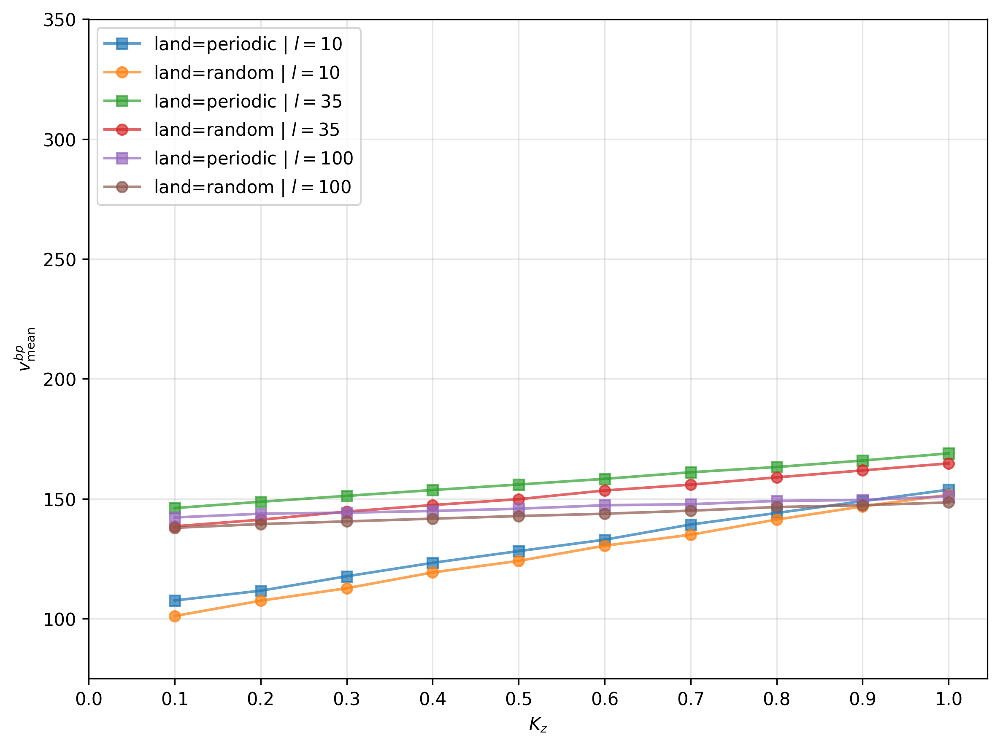

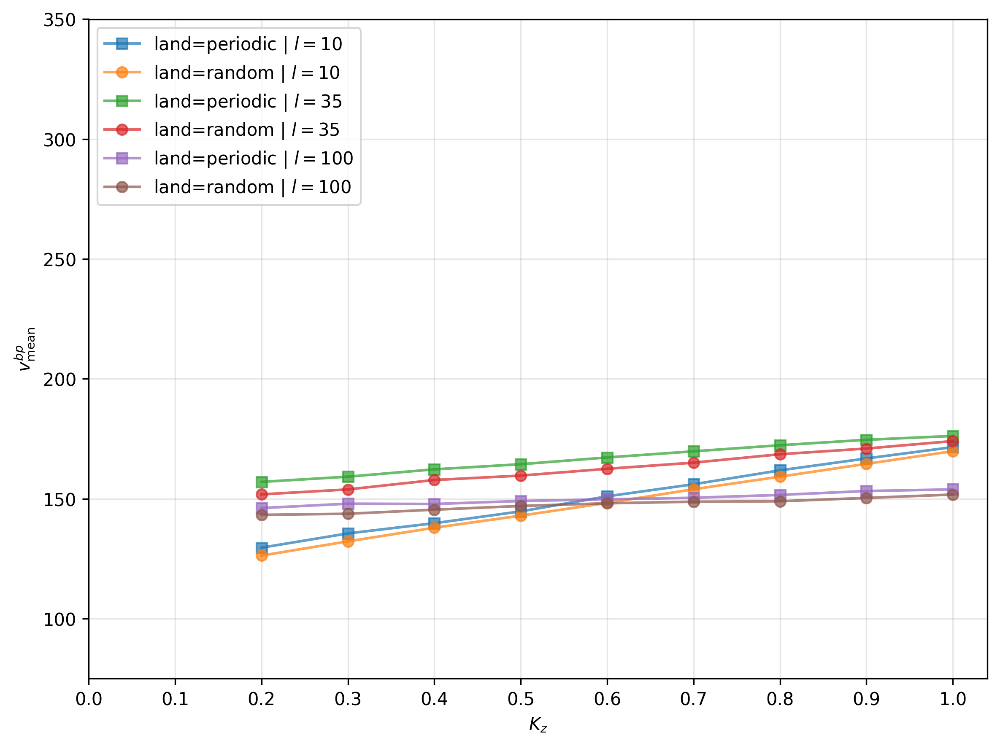

...

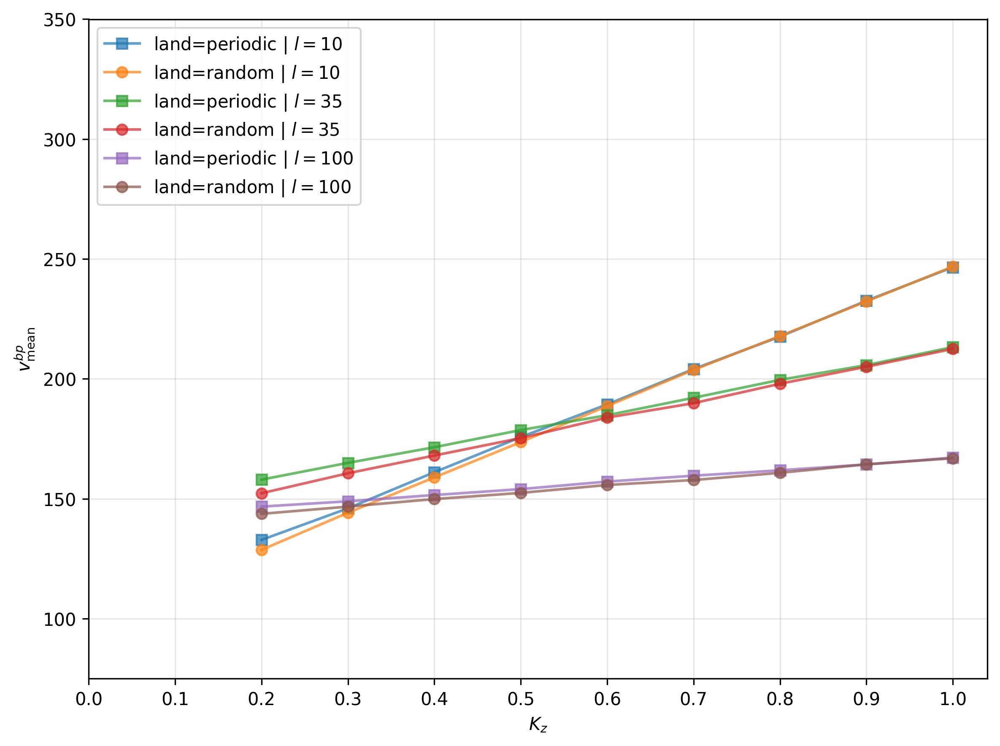

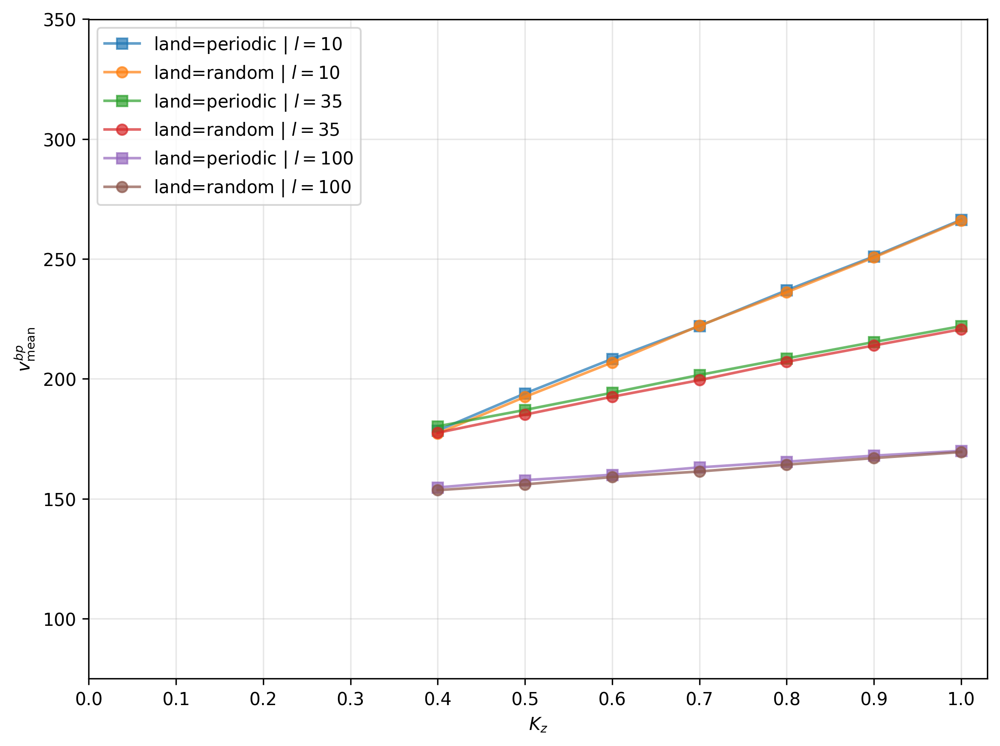

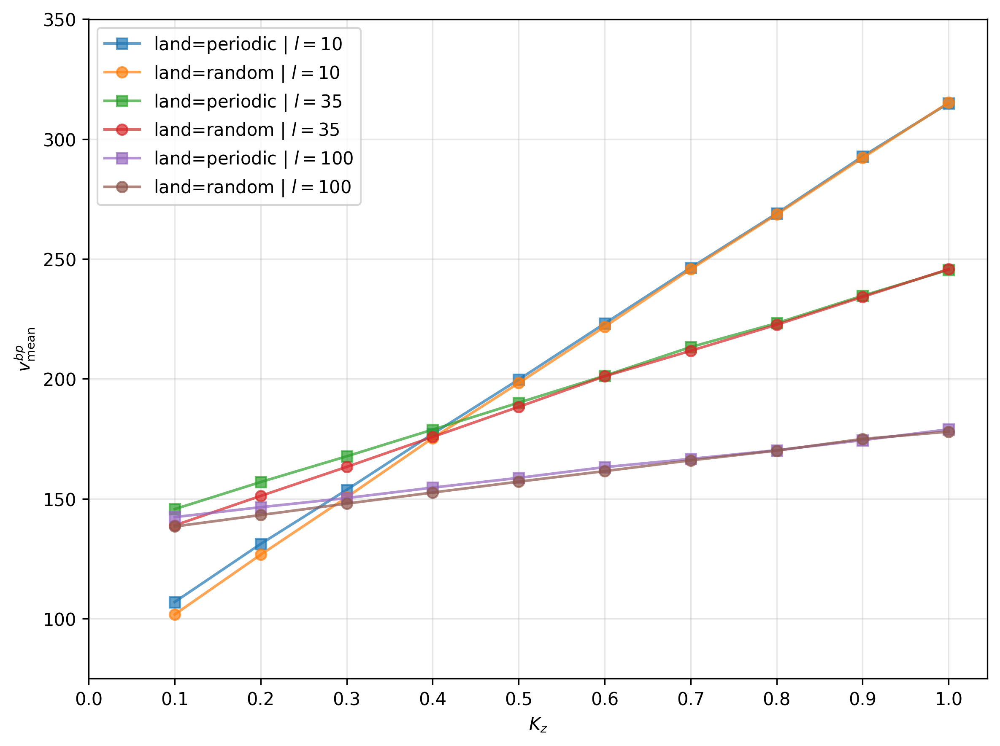

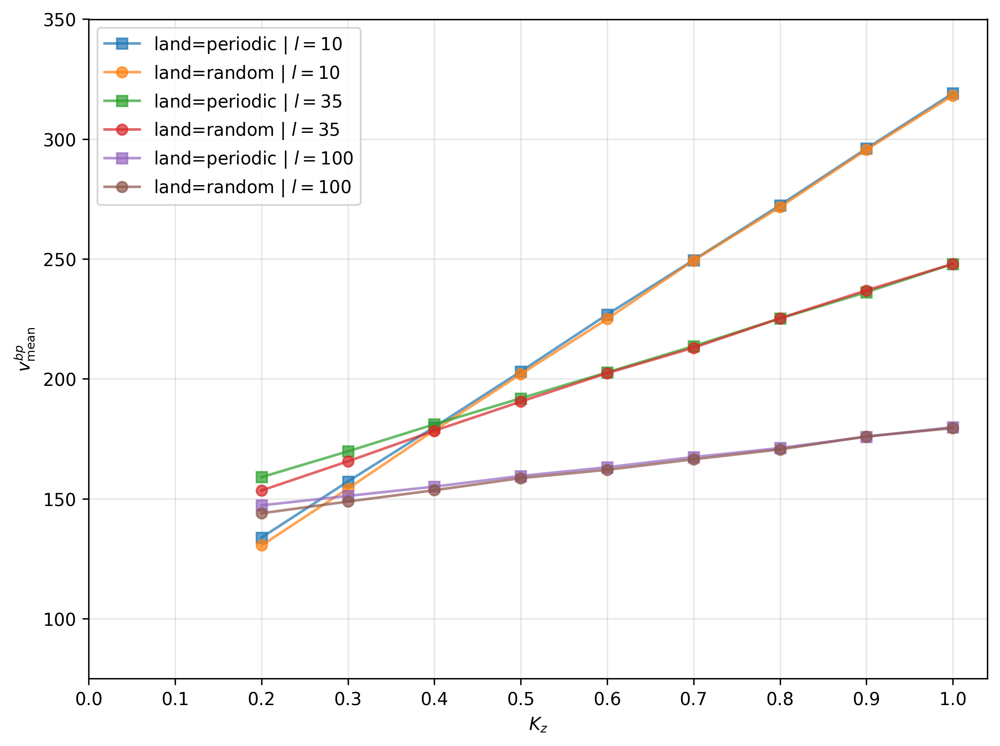

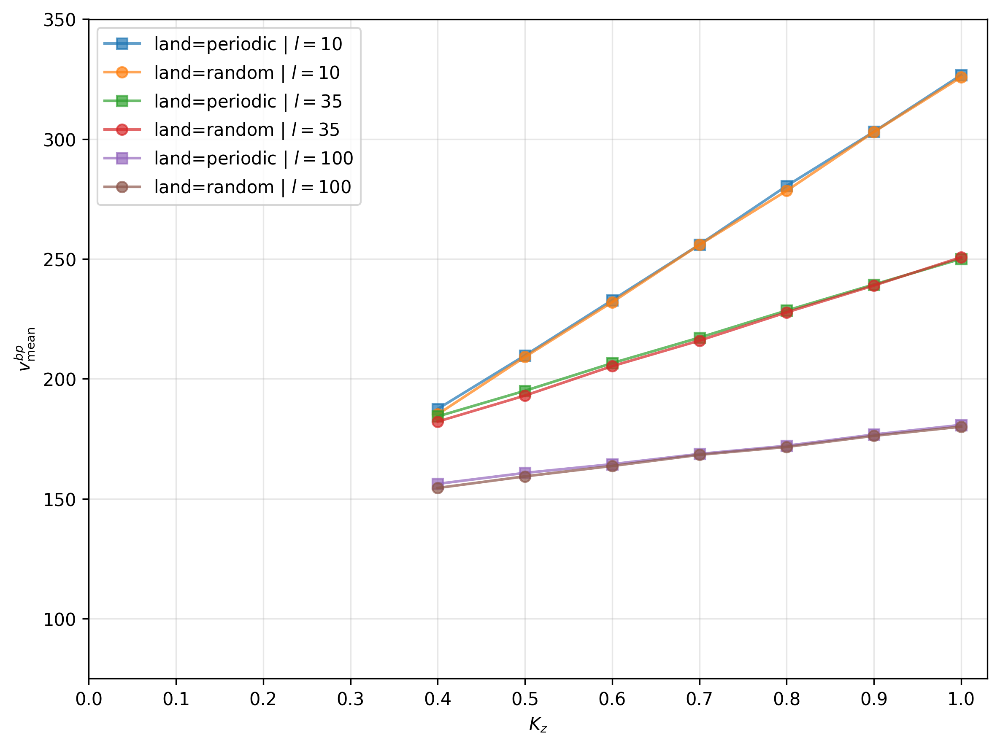

In [29]:
# - Paramètres -----
V_COL = "vc_mean"
# YLIM  = (75, 325)

# - Données -----
df = sel(load_actifull(), alphar=ALPHAR_ACTIVE)

# - Plots : une figure par (krel, Kp) -----
for krel in sorted(df["krel"].unique().to_list()):
    for Kp in sorted(df["Kp"].unique().to_list()):

        sub = keep_kz_ge_kp(sel(df, krel=krel, Kp=Kp))

        plot_curves(
            sub, x="Kz", y=V_COL,
            xlabel=r"$K_z$", ylabel=r"$v_{\mathrm{mean}}$" if V_COL == "v_mean" else r"$v^{bp}_{\mathrm{mean}}$",
            # title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$",
            xticks=np.arange(0, 1.1, 0.10), ylim=[20,100] if V_COL == "v_mean" else [75,350],
            legend_loc="upper left",
        )

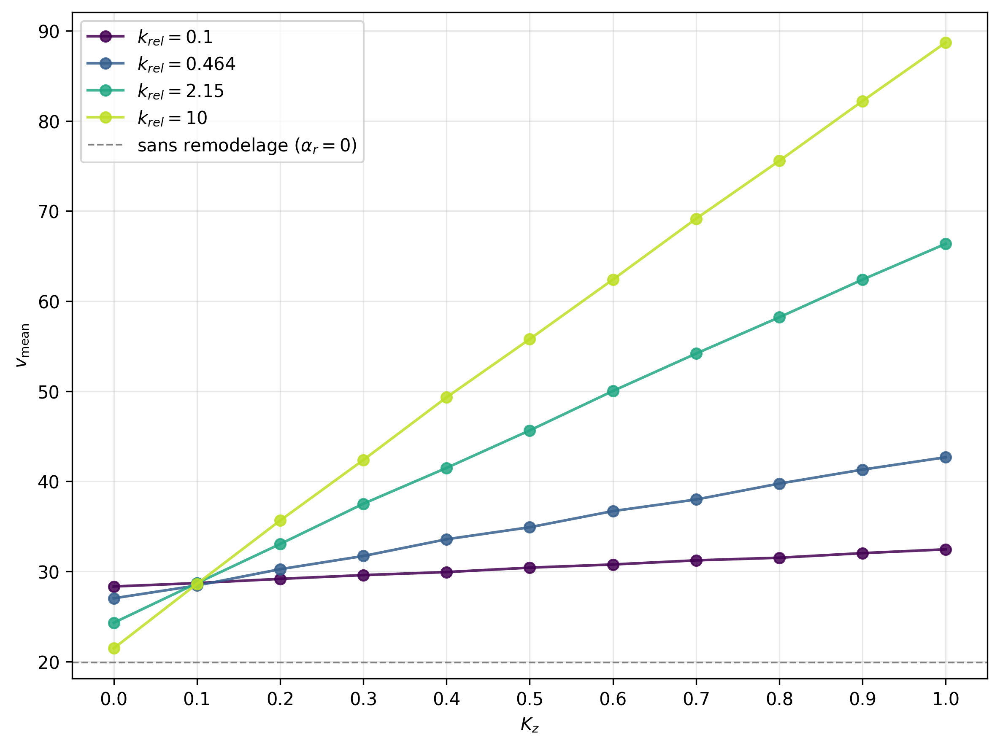

In [10]:
# - Paramètres -----
V_COL  = "v_mean"          # "vc_mean" pour la version bp
LAND, L, KP, ALPHAR = "random", 10, 0.1, 1.0

# - Données (non filtrées sur alphar, pour disposer aussi de alphar = 0) -----
df = sel(load_actifull(filtered=False), mu=MU, theta=THETA, rrest=RREST, land=LAND, l=L)

sub = sel(df, Kp=KP, alphar=ALPHAR)
# Référence : sans remodelage (alphar = 0), moyennée sur Kp, Kz, krel
base = sel(df, alphar=0.0)
v_base = base[V_COL].mean() if not base.is_empty() else None

# - Plot : une courbe par krel -----
krels  = sorted(sub["krel"].unique().to_list())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(krels)))

plt.figure(figsize=FIGSIZE, dpi=DPI)
for krel, color in zip(krels, colors):
    s = sel(sub, krel=krel).sort("Kz")
    plt.plot(
        s["Kz"].to_numpy(), s[V_COL].to_numpy(),
        marker=MARKERS.get(LAND, "o"), color=color, alpha=0.85,
        label=rf"$k_{{rel}} = {krel:.3g}$",
    )

if v_base is not None:
    plt.axhline(v_base, color="grey", ls="--", lw=1, label=r"sans remodelage ($\alpha_r = 0$)")

# plt.title(rf"actif sans mémoire | land={LAND} | $l={L}$ | $K_p={KP:g}$ | $\alpha_r={ALPHAR:g}$")
plt.xlabel(r"$K_z$")
plt.ylabel(r"$v_{\mathrm{mean}}$" if V_COL == "v_mean" else r"$v_{c,\mathrm{mean}}$")
plt.xticks(np.arange(0, 1.1, 0.10))
plt.grid(True, alpha=0.30)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

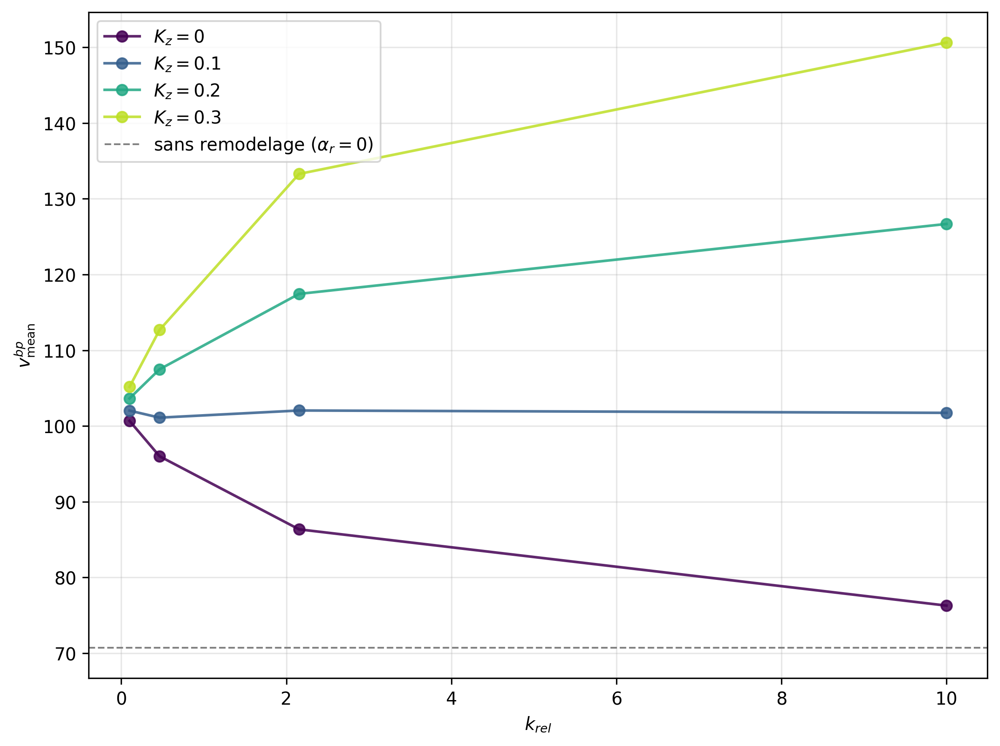

In [21]:
# - Paramètres -----
V_COL  = "vc_mean"          # "vc_mean" pour la version bp
LAND, L, KP, ALPHAR = "random", 10, 0.1, 1.0

# - Données (non filtrées sur alphar, pour disposer aussi de alphar = 0) -----
df = sel(load_actifull(filtered=False), mu=MU, theta=THETA, rrest=RREST, land=LAND, l=L)

sub = sel(df, Kp=KP, alphar=ALPHAR)
# Référence : sans remodelage (alphar = 0), moyennée sur Kp, Kz, krel
base = sel(df, alphar=0.0)
v_base = base[V_COL].mean() if not base.is_empty() else None

# - Plot : une courbe par krel -----
krels  = sorted(sub["krel"].unique().to_list())
Kzs    = sorted(sub["Kz"].unique().to_list())

colors = plt.cm.viridis(np.linspace(0, 0.9, len(krels)))

plt.figure(figsize=FIGSIZE, dpi=DPI)
for Kz, color in zip(Kzs, colors):
    s = sel(sub, Kz=Kz).sort("krel")
    plt.plot(
        s["krel"].to_numpy(), s[V_COL].to_numpy(),
        marker=MARKERS.get(LAND, "o"), color=color, alpha=0.85,
        label=rf"$K_z = {Kz:.3g}$",
    )

if v_base is not None:
    plt.axhline(v_base, color="grey", ls="--", lw=1, label=r"sans remodelage ($\alpha_r = 0$)")

# plt.title(rf"actif sans mémoire | land={LAND} | $l={L}$ | $K_p={KP:g}$ | $\alpha_r={ALPHAR:g}$")
plt.xlabel(r"$k_{{rel}}$")
plt.ylabel(r"$v_{\mathrm{mean}}$" if V_COL == "v_mean" else r"$v^{bp}_{\mathrm{mean}}$")
# plt.xticks(np.arange(0, 1.1, 0.10))
plt.grid(True, alpha=0.30)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------------------------------------------------------------

# Actif avec mémoire

## Aperçu des données

In [11]:
# - Données brutes (avant filtrage) -----
df_actimemo_all = load_actimemo(filtered=False)

describe_params(df_actimemo_all)

(4752, 61)
algo   : ['2S']
fact   : [ True]
mode   : ['actimemo']
dstr   : [False]
land   : ['periodic' 'random']
s      : [35]
l      : [ 10  35 100]
bpmin  : [0]
mu     : [150]
theta  : [100]
alphaf : [1.]
alphao : [0.]
beta   : [0.]
rcapt  : [2.]
rrest  : [2.]
alphac : [0.67]
alphad : [0.]
alphar : [0.  0.2 0.4 0.6 0.8 1. ]
krel   : [ 0.1         0.46415888  2.15443469 10.        ]
Kp     : [0.1        0.17782794 0.31622777]
Kz     : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## Vérification sur un run : moyenne de `results_c` vs `results_mean` × c

In [12]:
# # - Données : un seul run -----
# df = pl.read_parquet(ROOT_VERIF)
# print(df)

# # - Facteur c = (l * c_linker + s * c_nucleo) / (l + s) -----
# s_run, l_run, mu_run = df["s"][0], df["l"][0], df["mu"][0]

# c_linker = 1
# c_nucleo = mu_run / s_run
# c = (l_run * c_linker + s_run * c_nucleo) / (l_run + s_run)

# results_mean = df["results_mean"][0].to_numpy()
# results_c    = df["results_c"][0].to_numpy()

# # - Plot -----
# plt.figure()
# plt.plot(np.mean(results_c, axis=0), label=r"moyenne de `results_c`")
# plt.plot(results_mean * c, label=r"`results_mean` $\times\ c$")
# plt.legend()
# plt.show()

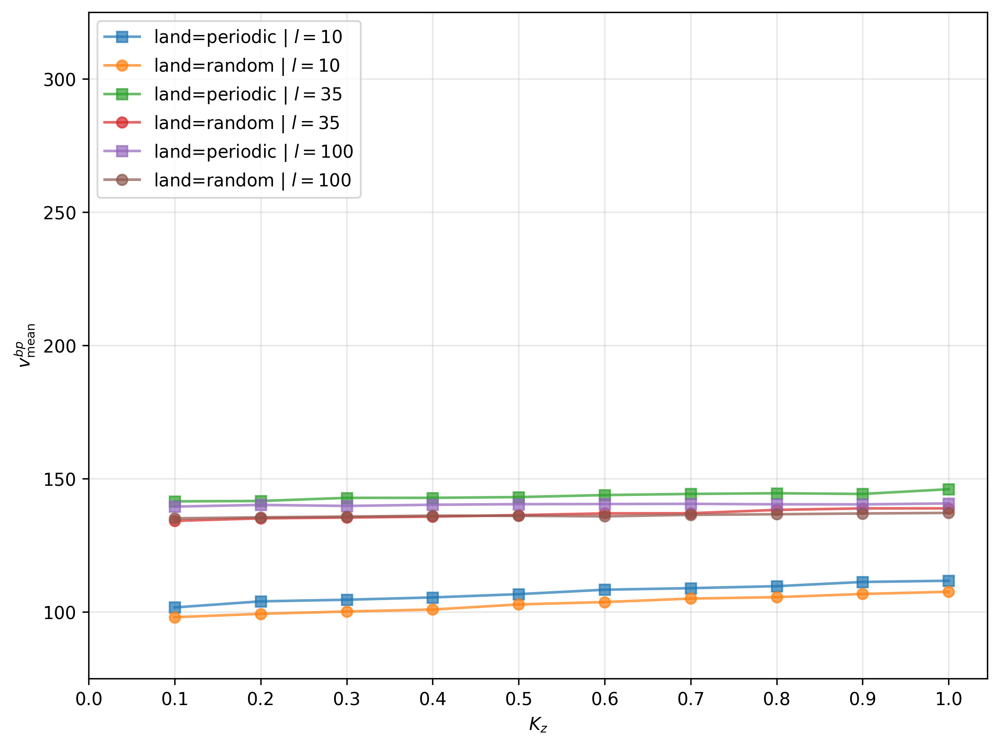

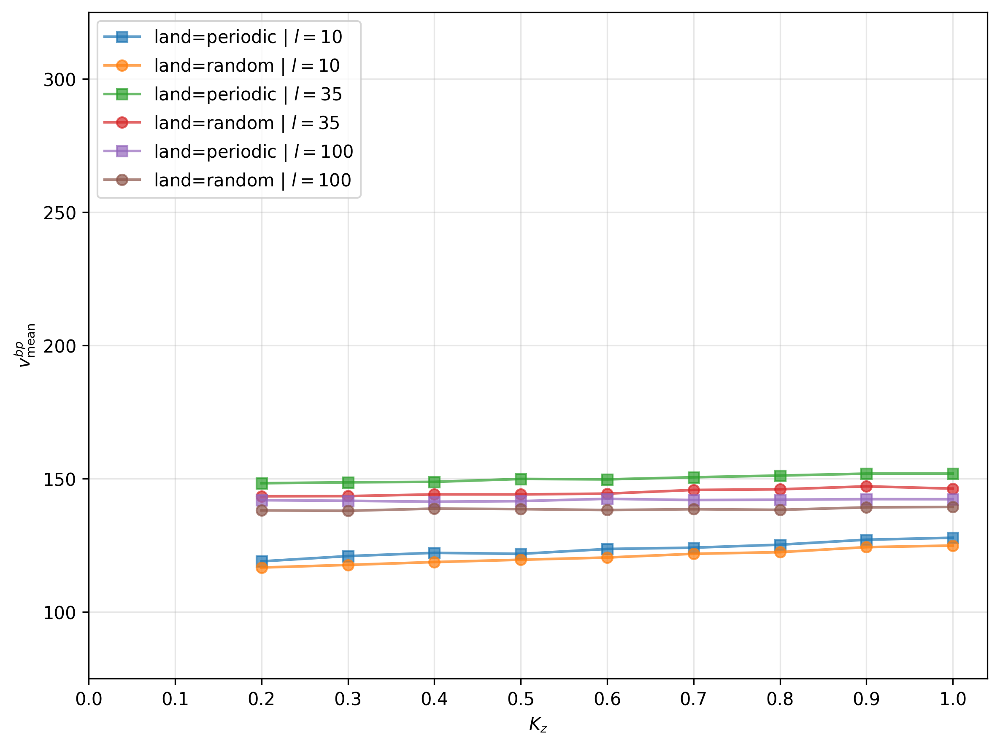

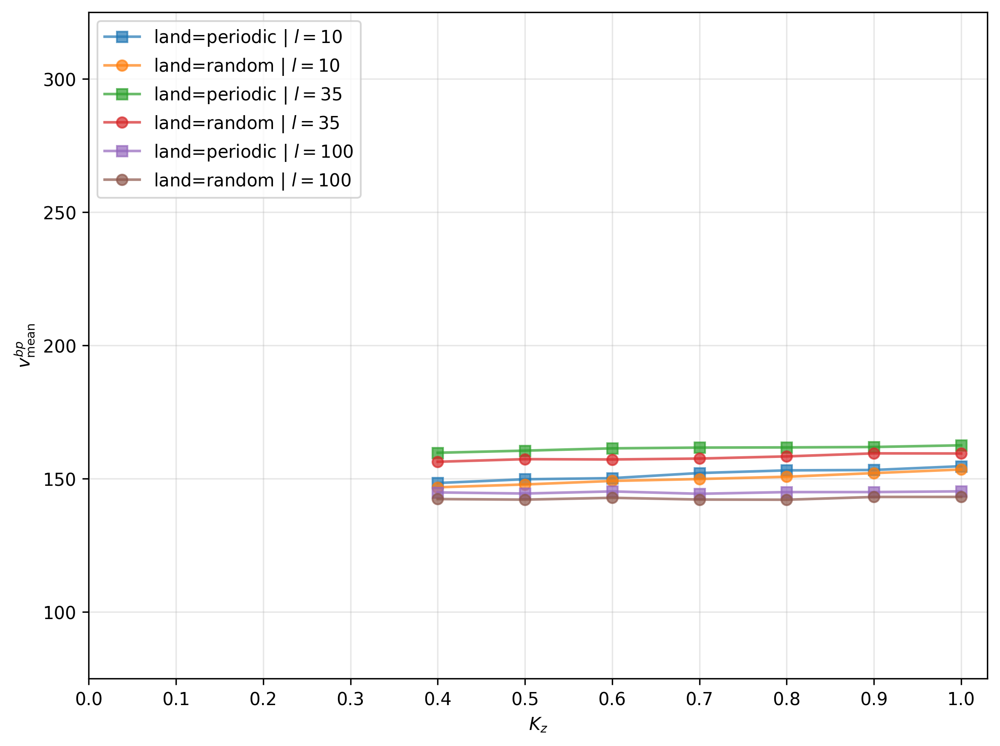

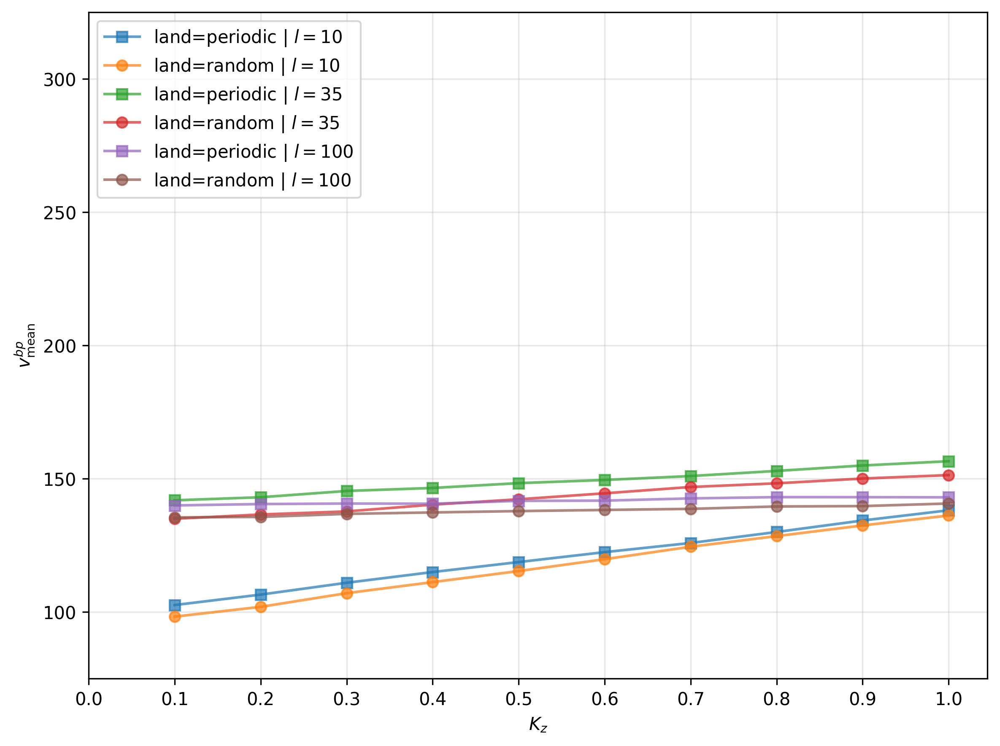

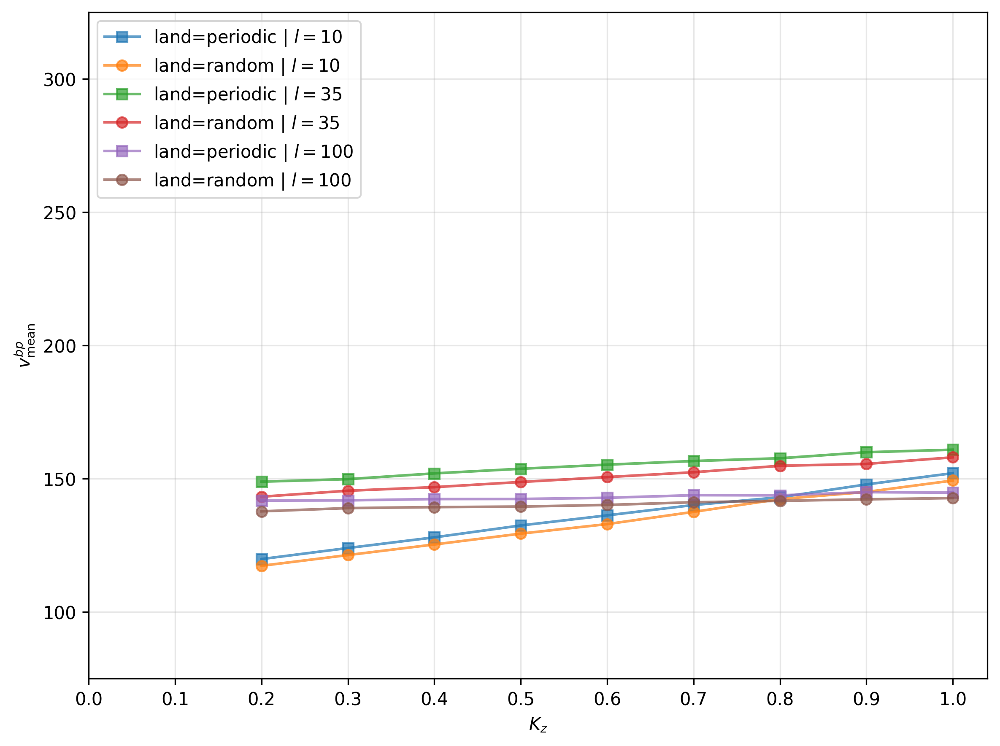

...

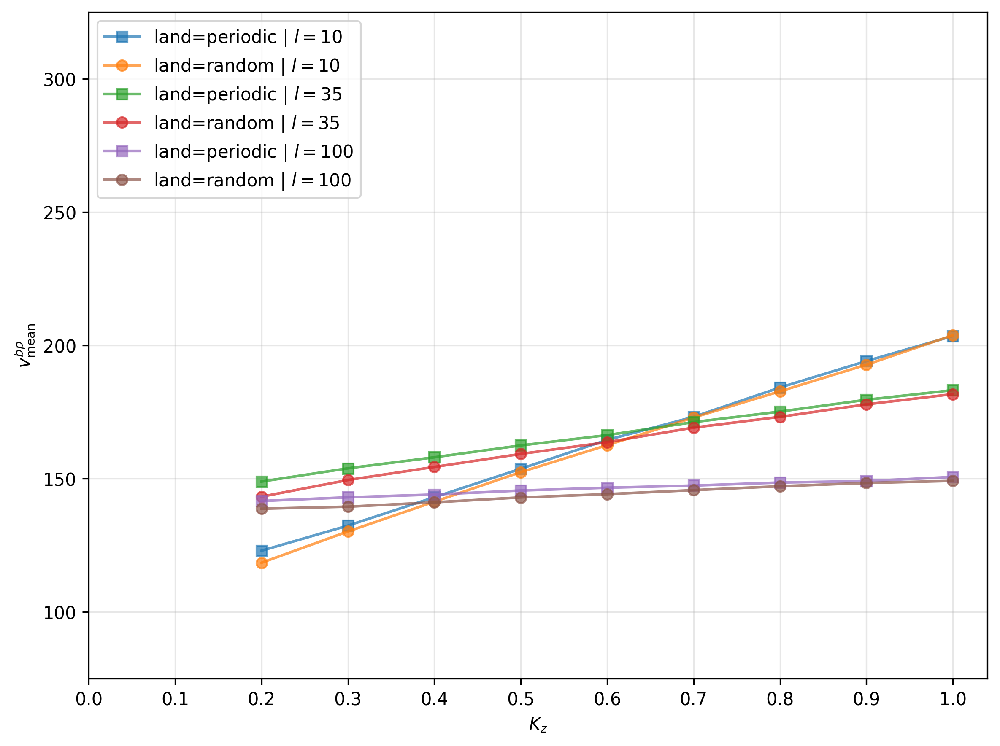

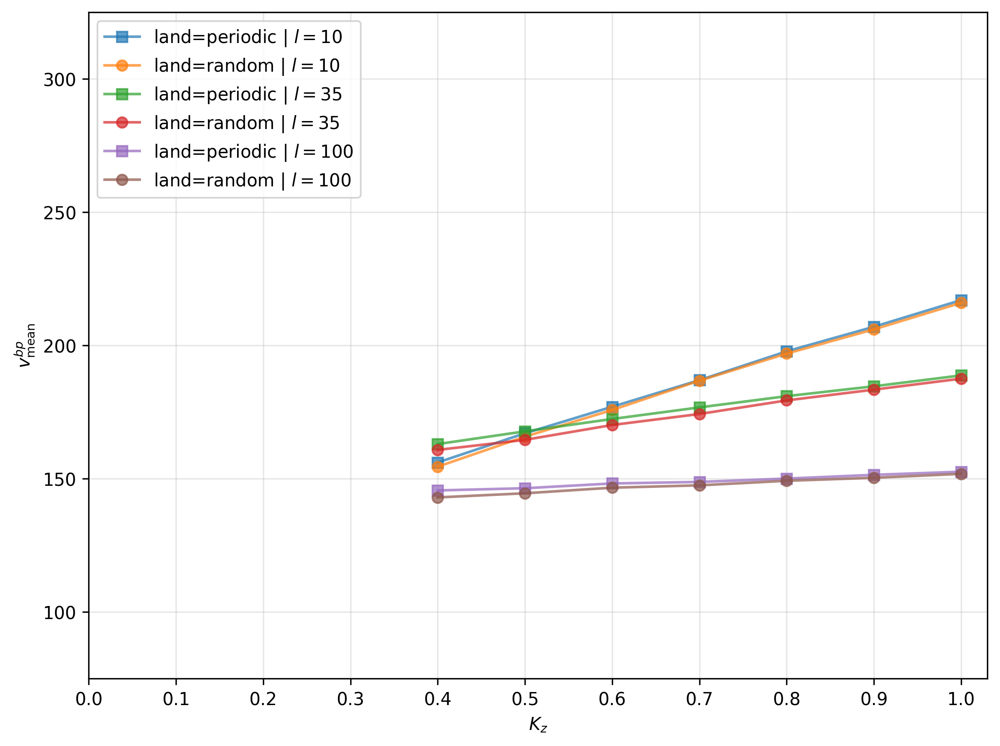

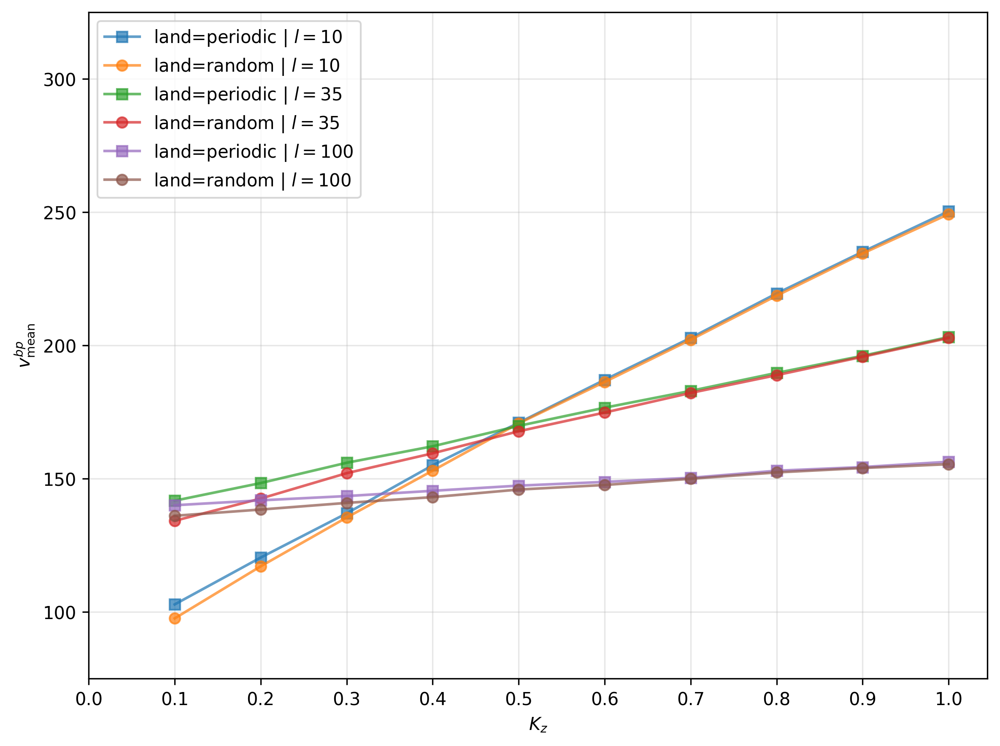

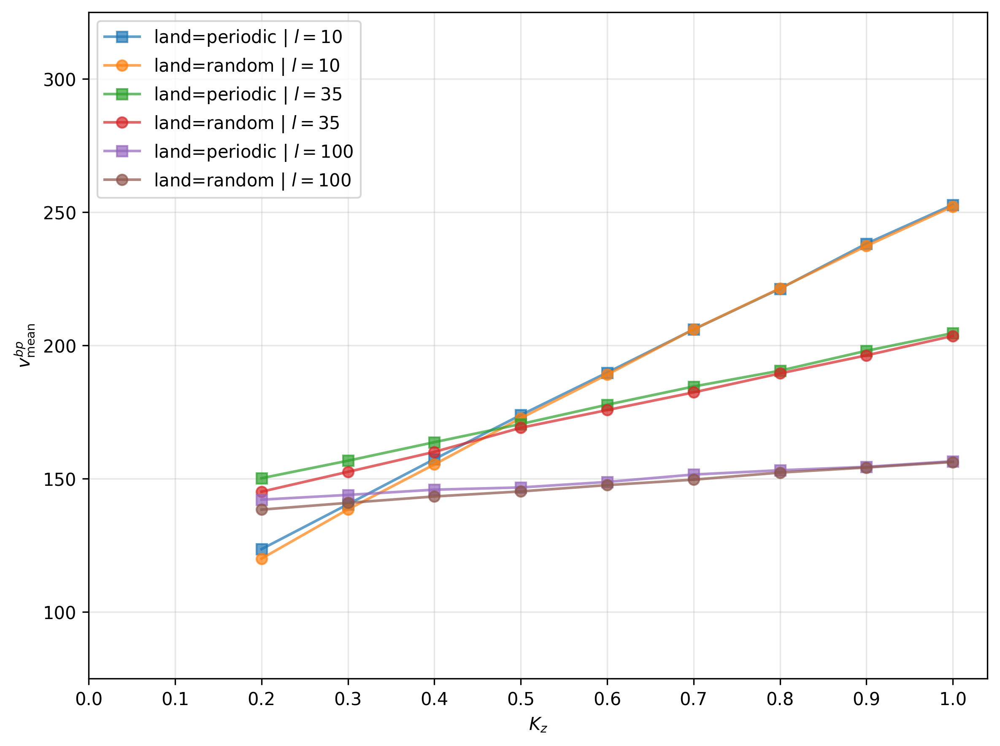

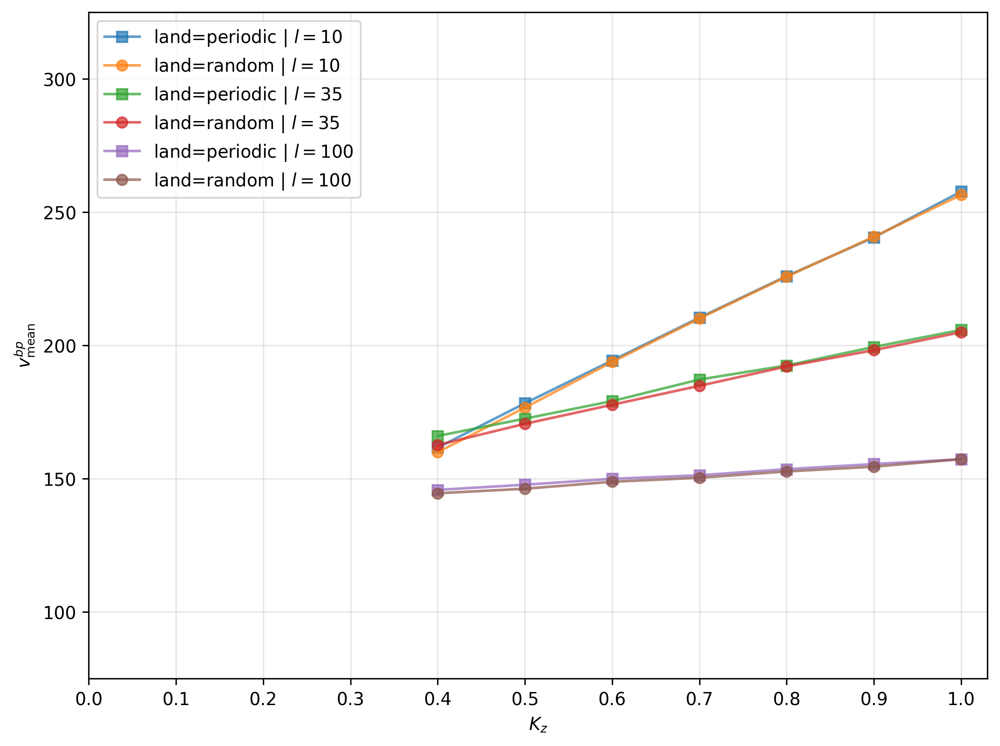

In [13]:
# - Paramètres -----
V_COL = "vc_mean"
YLIM  = (75, 325)

# - Données -----
df = sel(load_actimemo(), alphar=ALPHAR_ACTIVE)

# - Plots : une figure par (krel, Kp) -----
for krel in sorted(df["krel"].unique().to_list()):
    for Kp in sorted(df["Kp"].unique().to_list()):

        sub = keep_kz_ge_kp(sel(df, krel=krel, Kp=Kp))

        plot_curves(
            sub, x="Kz", y=V_COL,
            xlabel=r"$K_z$", ylabel=r"$v^{bp}_{\mathrm{mean}}$",
            # title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$",
            xticks=np.arange(0, 1.1, 0.10), ylim=YLIM,
            legend_loc="upper left",
        )

# Gains de vitesse entre les cas

Chaque gain est calculé **à paramètres identiques** (`compute_gain`) et vaut `G = cas étudié / cas de référence` :

| Section | Cas étudié | Cas de référence |
|---|---|---|
| 1 | remodelage passif | sans remodelage |
| 2 | remodelage actif sans mémoire | remodelage passif |
| 3 | remodelage actif avec mémoire | remodelage actif sans mémoire |

`report_overlap` affiche, avant chaque calcul, les paramètres qui ne sont pas identiques entre les deux jeux de données (seules les valeurs communes donnent un gain).

## 1. Sans remodelage → remodelage passif

### $G_{v_{\mathrm{mean}}}$

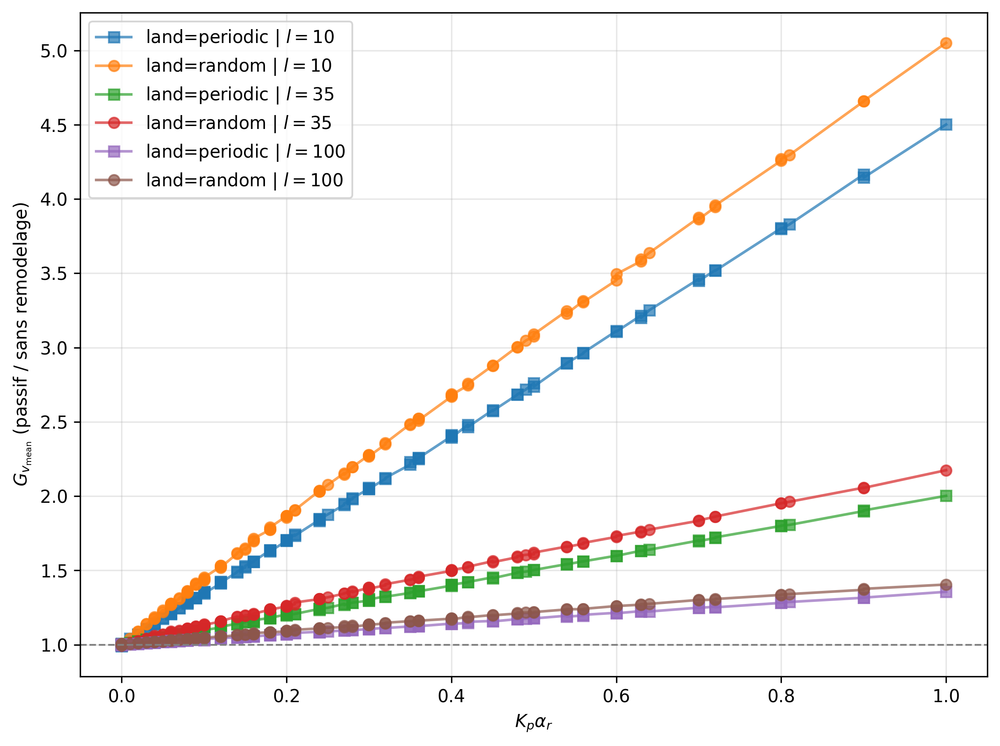

In [13]:
# - Paramètres -----
V_COL = "v_mean"

# - Données -----
df = load_passive()

# - Gain : référence = alphar = 0 (pas de remodelage), moyennée sur Kp -----
g = compute_gain(
    df, sel(df, alphar=0.0), value=V_COL,
    average_ref_over=("alphar", "Kp"),
)
g = g.with_columns((pl.col("Kp") * pl.col("alphar")).alias("Kpalphar"))

# - Plot -----
plot_curves(
    g, x="Kpalphar", y="gain",
    xlabel=r"$K_p \alpha_r$", ylabel=r"$G_{v_{\mathrm{mean}}}$ (passif / sans remodelage)",
    hline=1,
)

## 2. Remodelage passif → remodelage actif sans mémoire

Paramètres qui diffèrent entre actif sans mémoire et passif :
alphar : cas étudié=[1.0] | référence=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | communs=[1.0]
krel    (non joint): cas étudié=[0.1, 0.464159, 2.154435, 10.0] | référence=[1.0] | communs=[]
Kp     : cas étudié=[0.1, 0.177828, 0.316228] | référence=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | communs=[0.1]
Kz      (non joint): cas étudié=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | référence=[0.0] | communs=[0.0]

shape: (10, 9)
┌──────────┬─────┬────────┬──────────┬───┬─────┬───────────┬───────────┬──────────┐
│ land     ┆ l   ┆ alphar ┆ krel     ┆ … ┆ Kz  ┆ v_num     ┆ v_ref     ┆ gain     │
│ ---      ┆ --- ┆ ---    ┆ ---      ┆   ┆ --- ┆ ---       ┆ ---       ┆ ---      │
│ str      ┆ i64 ┆ f64    ┆ f64      ┆   ┆ f64 ┆ f64       ┆ f64       ┆ f64      │
╞══════════╪═════╪════════╪══════════╪═══╪═════╪═══════════╪═══════════╪══════════╡
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1      ┆ … ┆ 0.

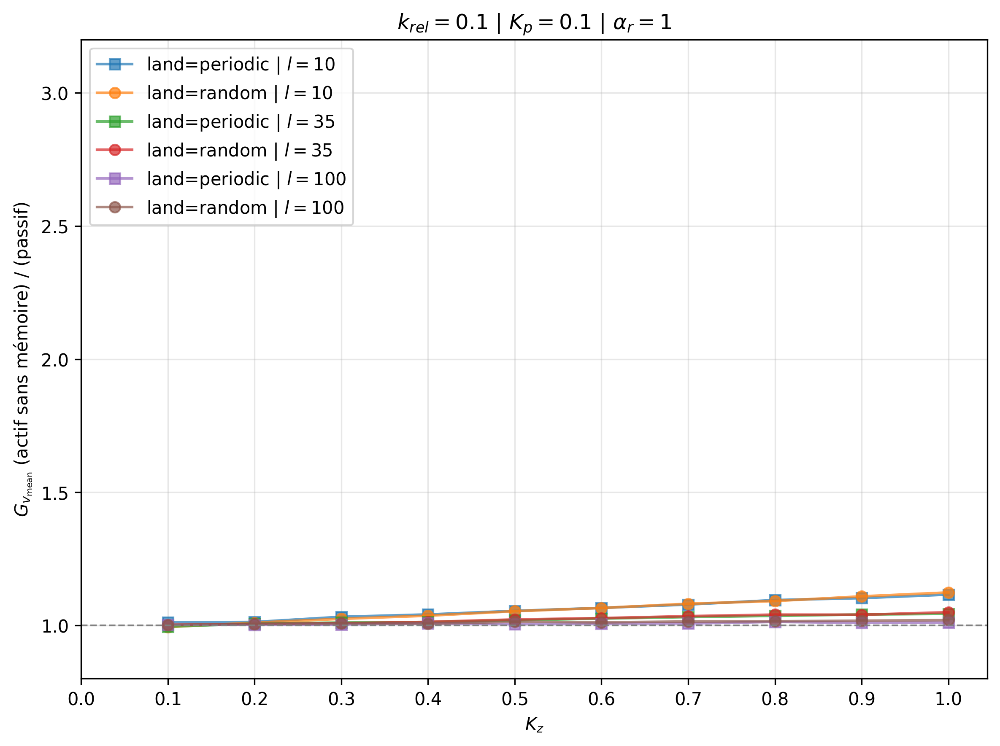

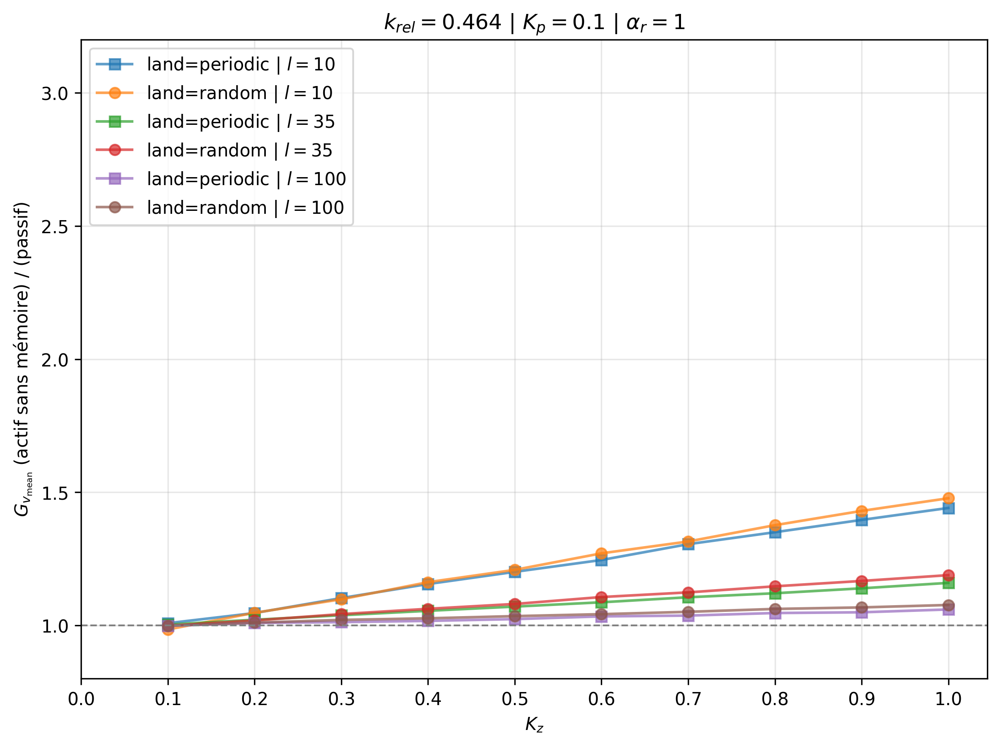

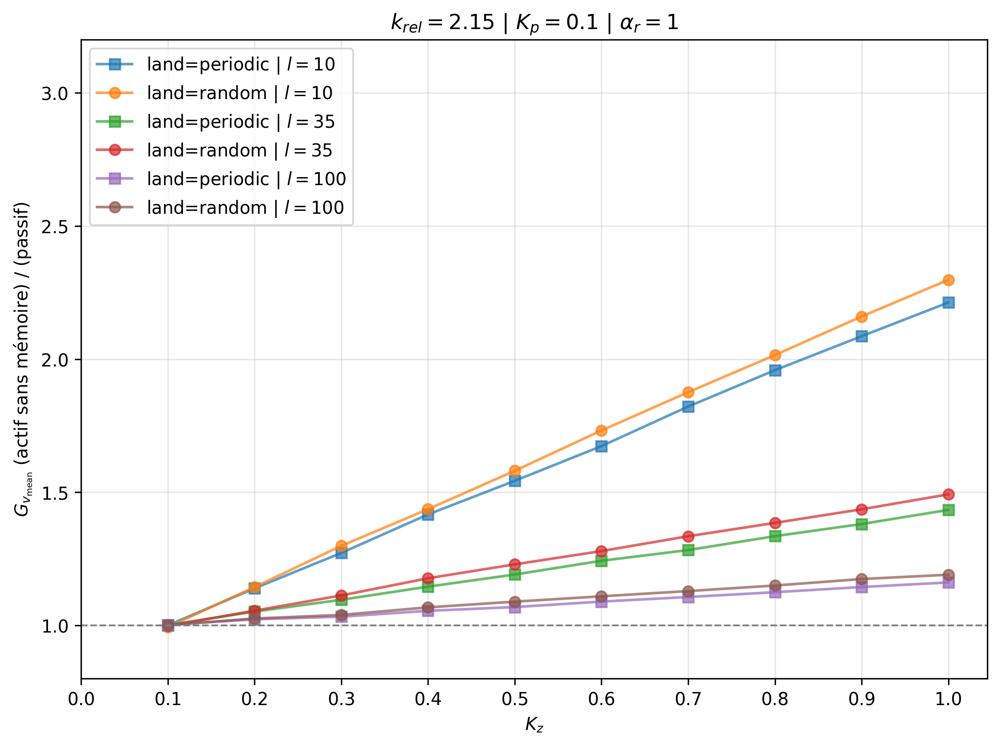

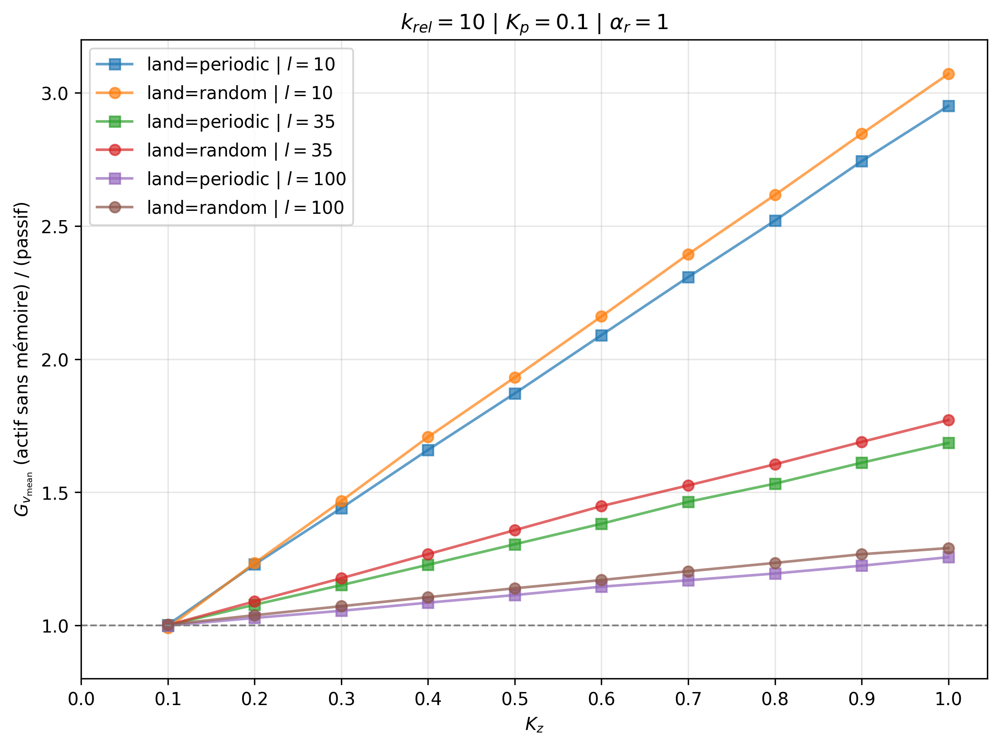

In [14]:
# ─────────────────────────────────────────────
# Paramètres
# ─────────────────────────────────────────────

V_COL = "v_mean"

INTERP_KP_REF = False

# ─────────────────────────────────────────────
# Données
# ─────────────────────────────────────────────

df_passive  = load_passive()
df_actifull = load_actifull()

EXCLUDE = ("Kz", "krel")

print("Paramètres qui diffèrent entre actif sans mémoire et passif :")
report_overlap(df_actifull, df_passive, exclude=EXCLUDE)

if INTERP_KP_REF:
    df_passive = interpolate_along(
        df_passive,
        "Kp",
        df_actifull["Kp"].unique().to_list(),
        [V_COL]
    )

# ─────────────────────────────────────────────
# Gain
#
# Le passif ne dépend PAS de krel :
#
# G = v_actif(krel, Kp, Kz) / v_passif(Kp, Kz)
# ─────────────────────────────────────────────

g = compute_gain(
    df_actifull,
    df_passive,
    value=V_COL,
    exclude=EXCLUDE
)

print()

print(
    g.select([
        "land",
        "l",
        "alphar",
        "krel",
        "Kp",
        "Kz",
        "v_num",
        "v_ref",
        "gain"
    ]).head(10)
)

# ─────────────────────────────────────────────
# Plots
# Une figure par combinaison krel / Kp
# ─────────────────────────────────────────────

for krel in sorted(df_actifull["krel"].unique().to_list()):

    for Kp in sorted(df_actifull["Kp"].unique().to_list()):

        sub = keep_kz_ge_kp(
            sel(
                g,
                alphar=ALPHAR_ACTIVE,
                krel=krel,
                Kp=Kp
            )
        )

        if sub.is_empty():
            continue

        plot_curves(
            sub,
            x="Kz",
            y="gain",
            xlabel=r"$K_z$",
            ylabel=r"$G_{v_{\mathrm{mean}}}$ (actif sans mémoire) / (passif)",
            title=(
                rf"$k_{{rel}} = {krel:.3g}$"
                rf" | $K_p = {Kp:.3g}$"
                rf" | $\alpha_r = {ALPHAR_ACTIVE:g}$"
            ),
            xticks=np.arange(0, 1.1, 0.10),
            ylim=[0.80, 3.20],
            hline=1,
            legend_loc="upper left",
        )

Paramètres qui diffèrent entre actif sans mémoire et passif :
alphar : cas étudié=[1.0] | référence=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | communs=[1.0]
krel    (non joint): cas étudié=[0.1, 0.464159, 2.154435, 10.0] | référence=[1.0] | communs=[]
Kp     : cas étudié=[0.1, 0.177828, 0.316228] | référence=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | communs=[0.1]
Kz      (non joint): cas étudié=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] | référence=[0.0] | communs=[0.0]

shape: (10, 9)
┌──────────┬─────┬────────┬──────────┬───┬─────┬────────────┬───────────┬──────────┐
│ land     ┆ l   ┆ alphar ┆ krel     ┆ … ┆ Kz  ┆ v_num      ┆ v_ref     ┆ gain     │
│ ---      ┆ --- ┆ ---    ┆ ---      ┆   ┆ --- ┆ ---        ┆ ---       ┆ ---      │
│ str      ┆ i64 ┆ f64    ┆ f64      ┆   ┆ f64 ┆ f64        ┆ f64       ┆ f64      │
╞══════════╪═════╪════════╪══════════╪═══╪═════╪════════════╪═══════════╪══════════╡
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1      ┆ …

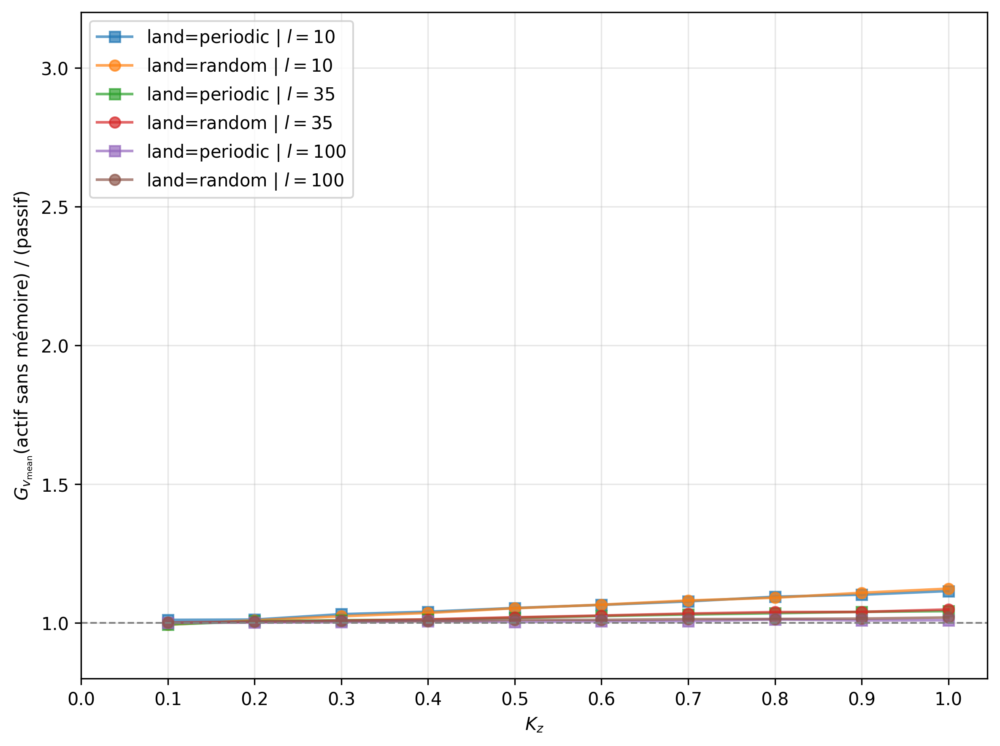

('$k_{rel} = 0.464$ | $K_p = 0.1$ | $\\alpha_r = 1$',)


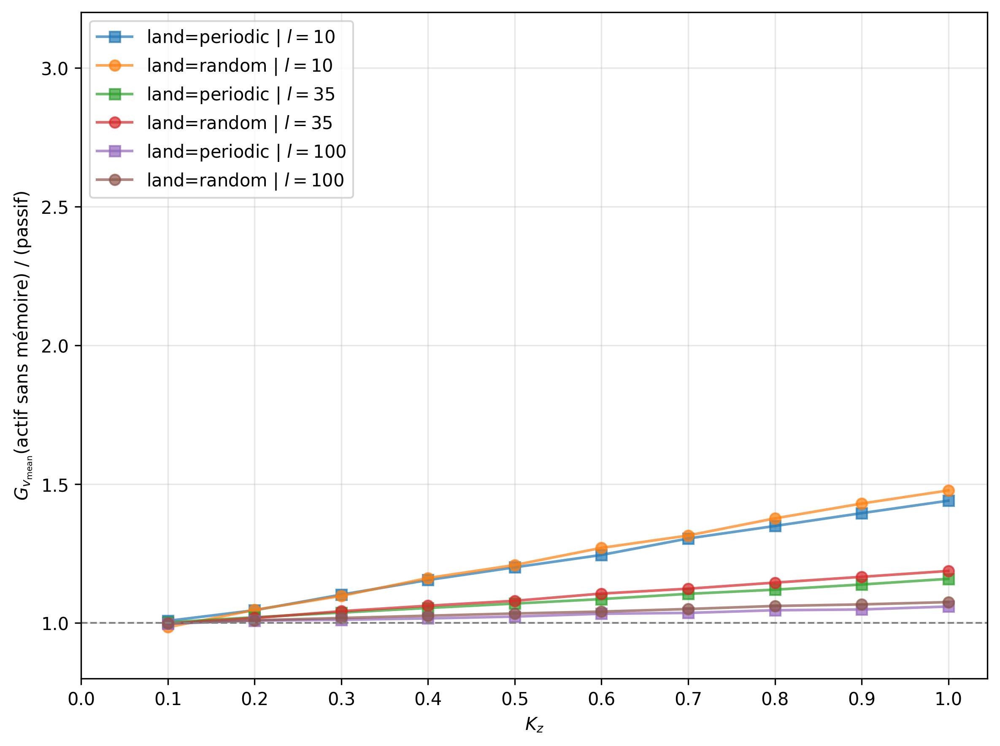

('$k_{rel} = 2.15$ | $K_p = 0.1$ | $\\alpha_r = 1$',)


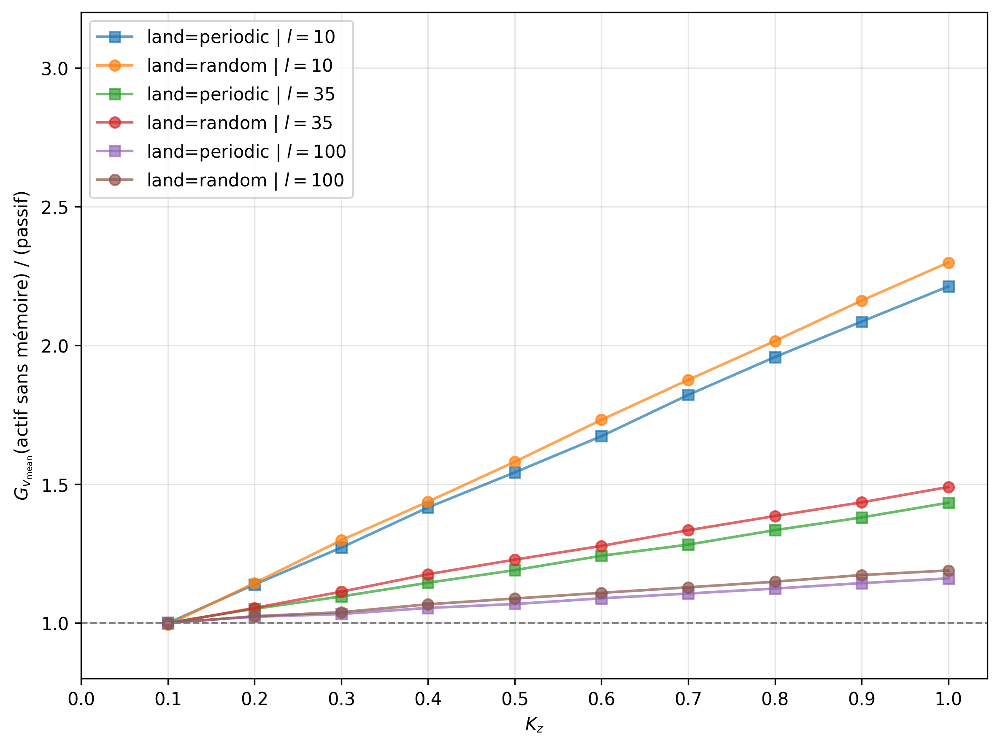

('$k_{rel} = 10$ | $K_p = 0.1$ | $\\alpha_r = 1$',)


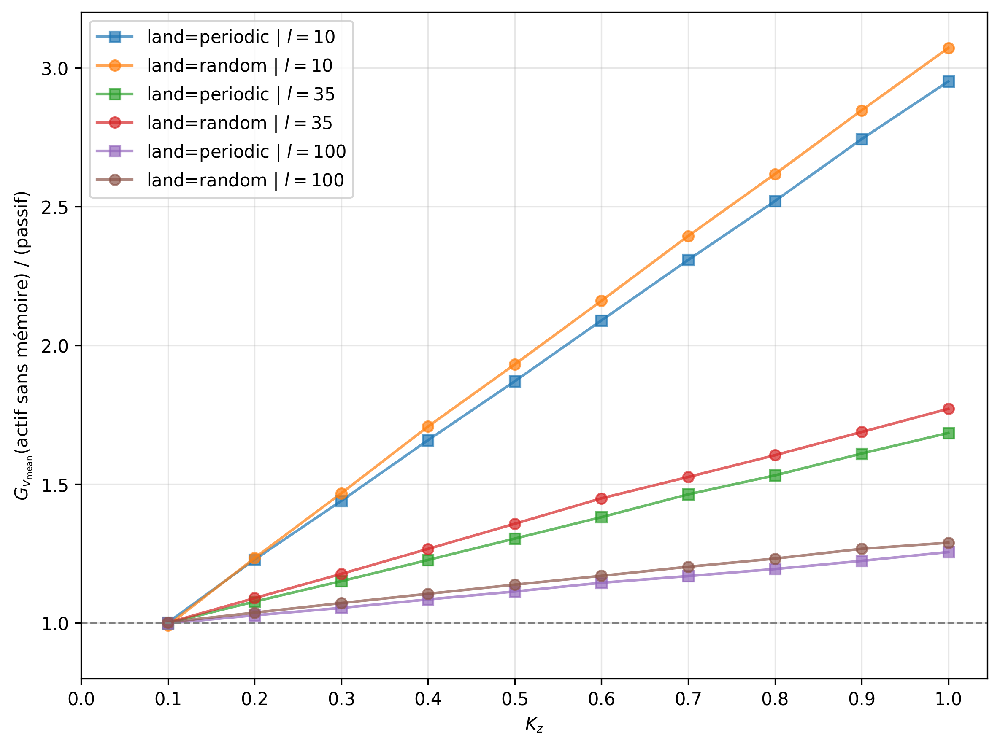

In [30]:
# - Paramètres -----
V_COL         = "vc_mean"   # "vc_mean" pour la version bp (le facteur c s'annule dans le rapport)
INTERP_KP_REF = False      # True : interpole la référence passive en Kp
                           #        (le passif n'a pas Kp = 0.178 ni 0.316, seulement des pas de 0.1)

# - Données -----
df_passive  = load_passive()          # mu, theta, rrest, Kz = KZ_PASSIVE
df_actifull = load_actifull()         # mu, theta, rrest

# Kz et krel n'existent que pour l'actif : on ne les joint pas
EXCLUDE = ("Kz", "krel")

print("Paramètres qui diffèrent entre actif sans mémoire et passif :")
report_overlap(df_actifull, df_passive, exclude=EXCLUDE)

if INTERP_KP_REF:
    df_passive = interpolate_along(
        df_passive, "Kp", df_actifull["Kp"].unique().to_list(), [V_COL]
    )

# - Gain G = v(actif sans mémoire) / v(passif) -----
g = compute_gain(df_actifull, df_passive, value=V_COL, exclude=EXCLUDE)
print()
print(g.select(["land", "l", "alphar", "krel", "Kp", "Kz", "v_num", "v_ref", "gain"]).head(10))

# - Plots : une figure par (krel, Kp), alphar = ALPHAR_ACTIVE -----
for krel in sorted(g["krel"].unique().to_list()):
    for Kp in sorted(g["Kp"].unique().to_list()):

        sub = keep_kz_ge_kp(sel(g, alphar=ALPHAR_ACTIVE, krel=krel, Kp=Kp))
        title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$ | $\alpha_r = {ALPHAR_ACTIVE:g}$",
        print(title)

        plot_curves(
            sub, x="Kz", y="gain",
            xlabel=r"$K_z$", ylabel=r"$G_{v_{\mathrm{mean}}}$(actif sans mémoire) / (passif)",
            # title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$ | $\alpha_r = {ALPHAR_ACTIVE:g}$",
            xticks=np.arange(0, 1.1, 0.10), ylim=[0.80, 3.20], hline=1,
            legend_loc="upper left",
        )
        

## 3. Remodelage actif sans mémoire → remodelage actif avec mémoire

Paramètres qui diffèrent entre actif avec mémoire et actif sans mémoire :

shape: (10, 9)
┌──────────┬─────┬────────┬──────┬───┬─────┬────────────┬────────────┬──────────┐
│ land     ┆ l   ┆ alphar ┆ krel ┆ … ┆ Kz  ┆ v_num      ┆ v_ref      ┆ gain     │
│ ---      ┆ --- ┆ ---    ┆ ---  ┆   ┆ --- ┆ ---        ┆ ---        ┆ ---      │
│ str      ┆ i64 ┆ f64    ┆ f64  ┆   ┆ f64 ┆ f64        ┆ f64        ┆ f64      │
╞══════════╪═════╪════════╪══════╪═══╪═════╪════════════╪════════════╪══════════╡
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.0 ┆ 101.473939 ┆ 105.184851 ┆ 0.96472  │
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.1 ┆ 101.696055 ┆ 107.95873  ┆ 0.94199  │
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.2 ┆ 103.978937 ┆ 108.069701 ┆ 0.962147 │
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.3 ┆ 104.588452 ┆ 110.149354 ┆ 0.949515 │
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.4 ┆ 105.450444 ┆ 111.090228 ┆ 0.949232 │
│ periodic ┆ 10  ┆ 1.0    ┆ 0.1  ┆ … ┆ 0.5 ┆ 106.685838 ┆ 112.538609 ┆ 0.947993 │
│ period

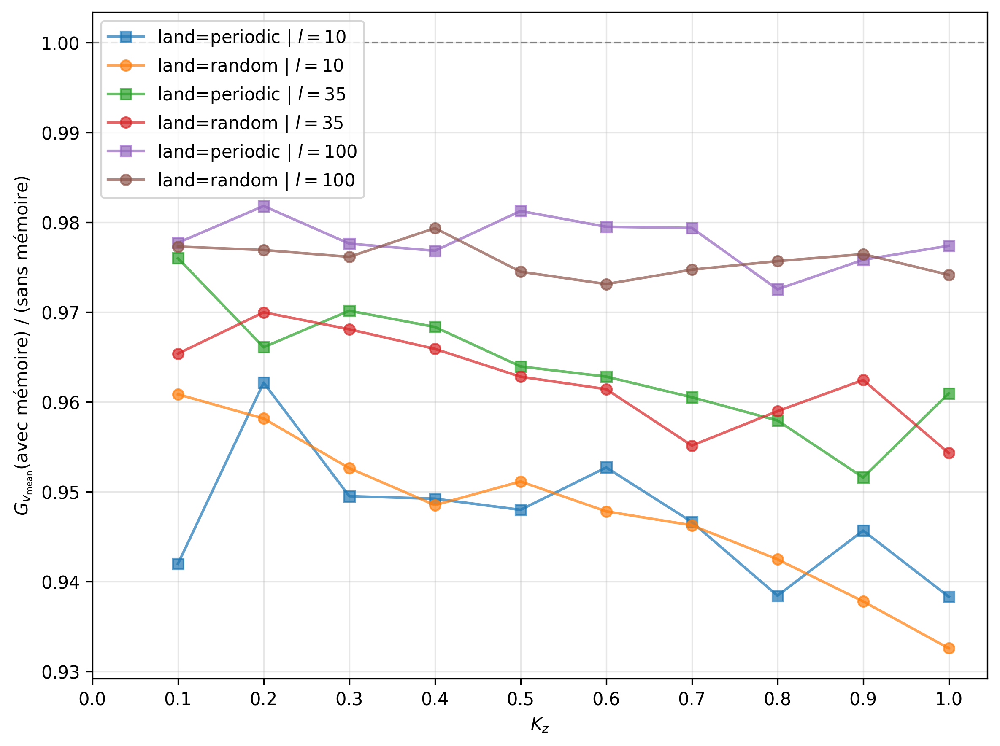

$k_{rel} = 0.1$ | $K_p = 0.178$ | $\alpha_r = 1$


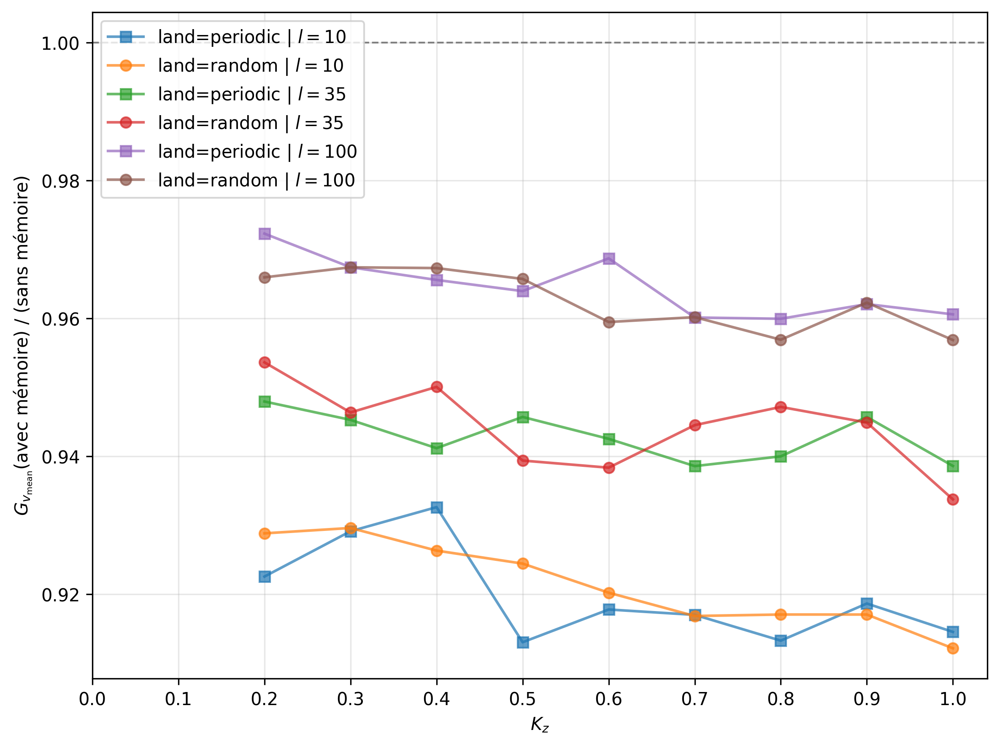

$k_{rel} = 0.1$ | $K_p = 0.316$ | $\alpha_r = 1$


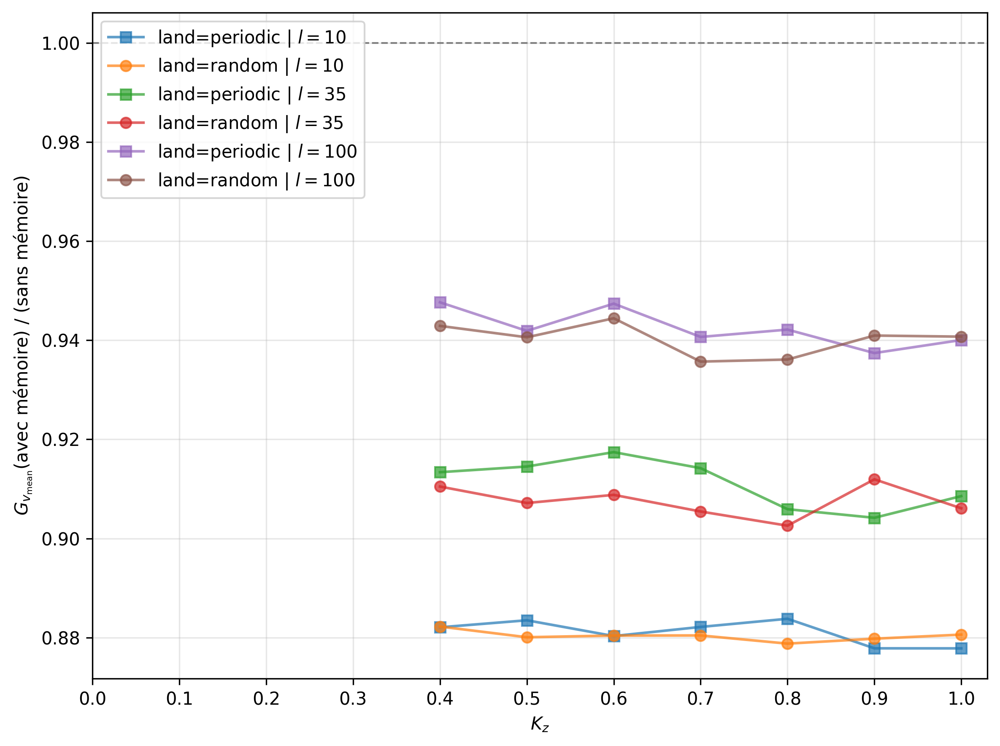

$k_{rel} = 0.464$ | $K_p = 0.1$ | $\alpha_r = 1$


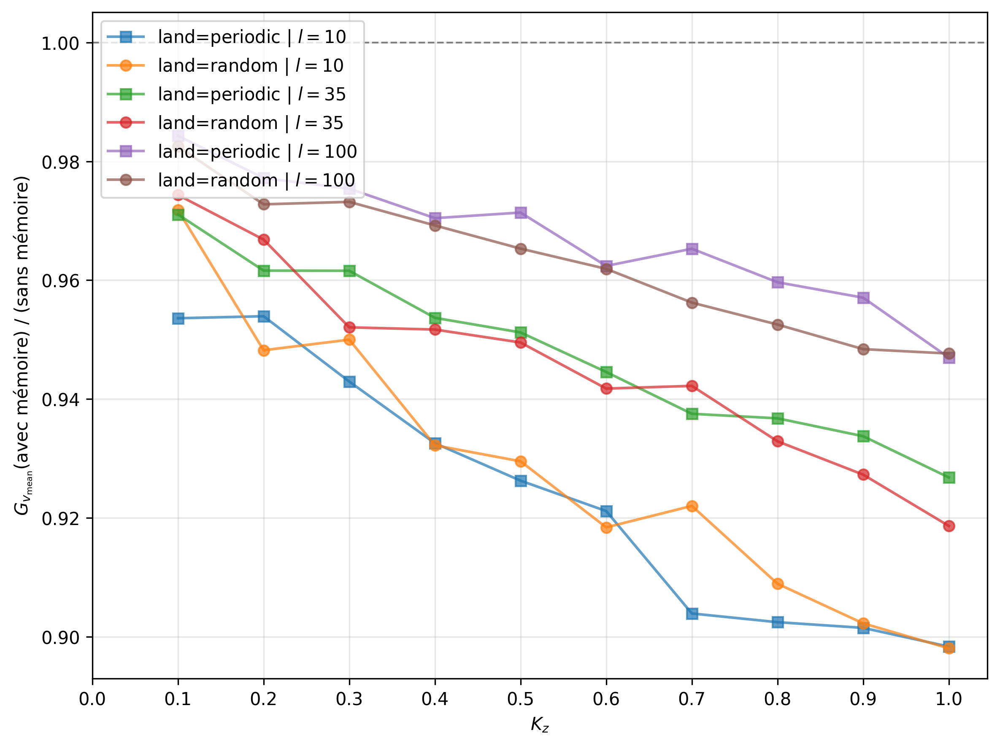

$k_{rel} = 0.464$ | $K_p = 0.178$ | $\alpha_r = 1$


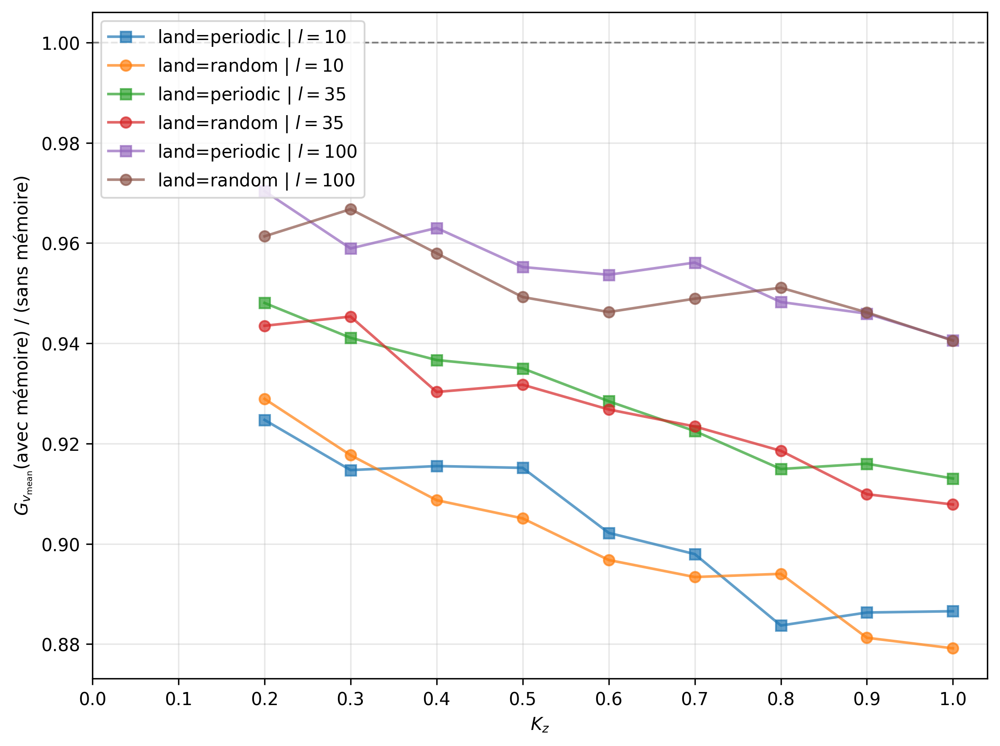

$k_{rel} = 0.464$ | $K_p = 0.316$ | $\alpha_r = 1$


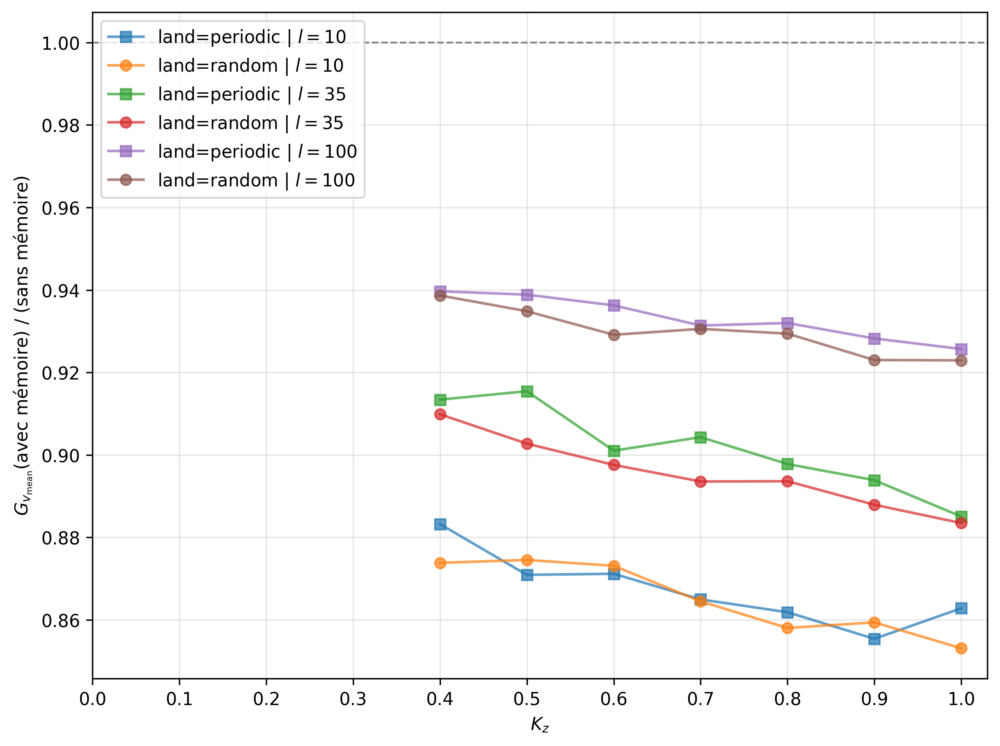

$k_{rel} = 2.15$ | $K_p = 0.1$ | $\alpha_r = 1$


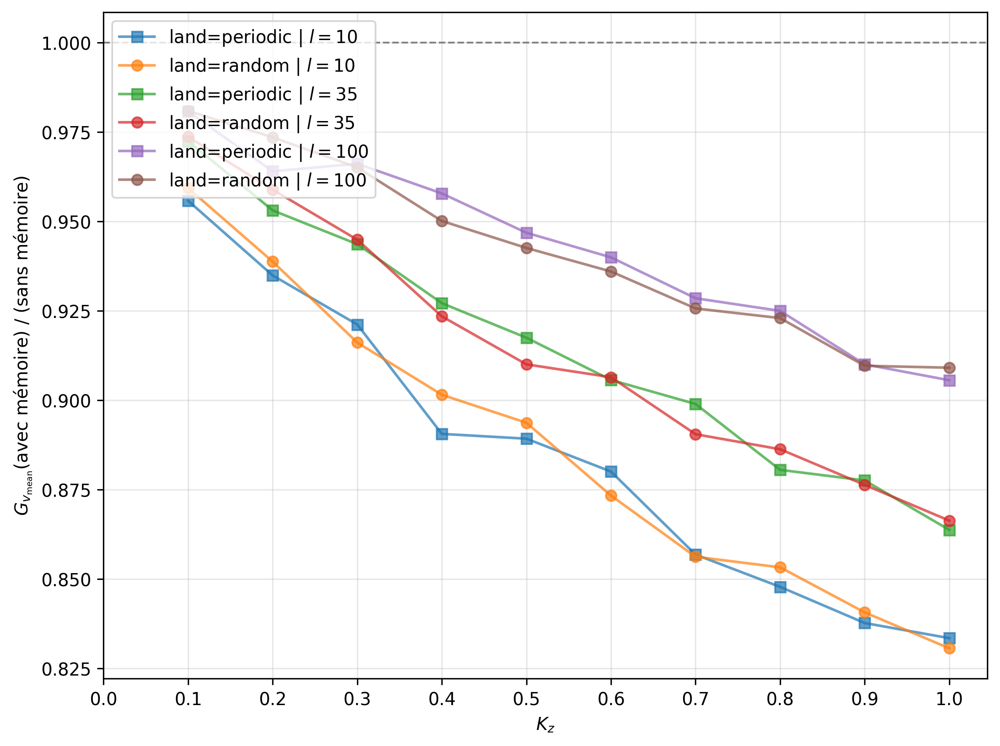

$k_{rel} = 2.15$ | $K_p = 0.178$ | $\alpha_r = 1$


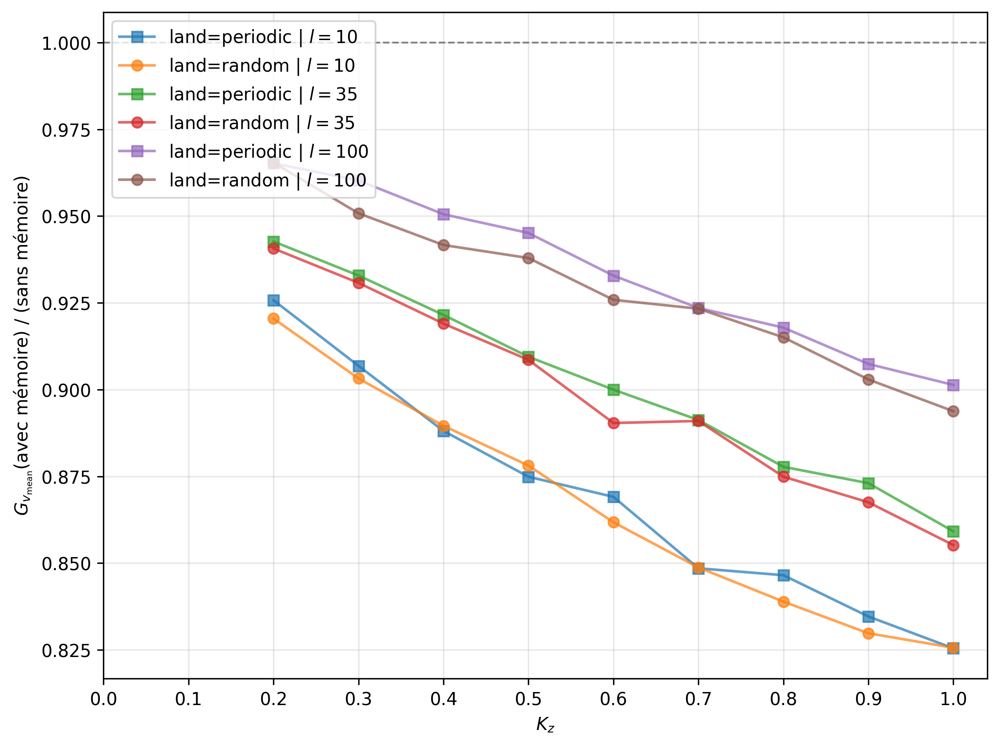

$k_{rel} = 2.15$ | $K_p = 0.316$ | $\alpha_r = 1$


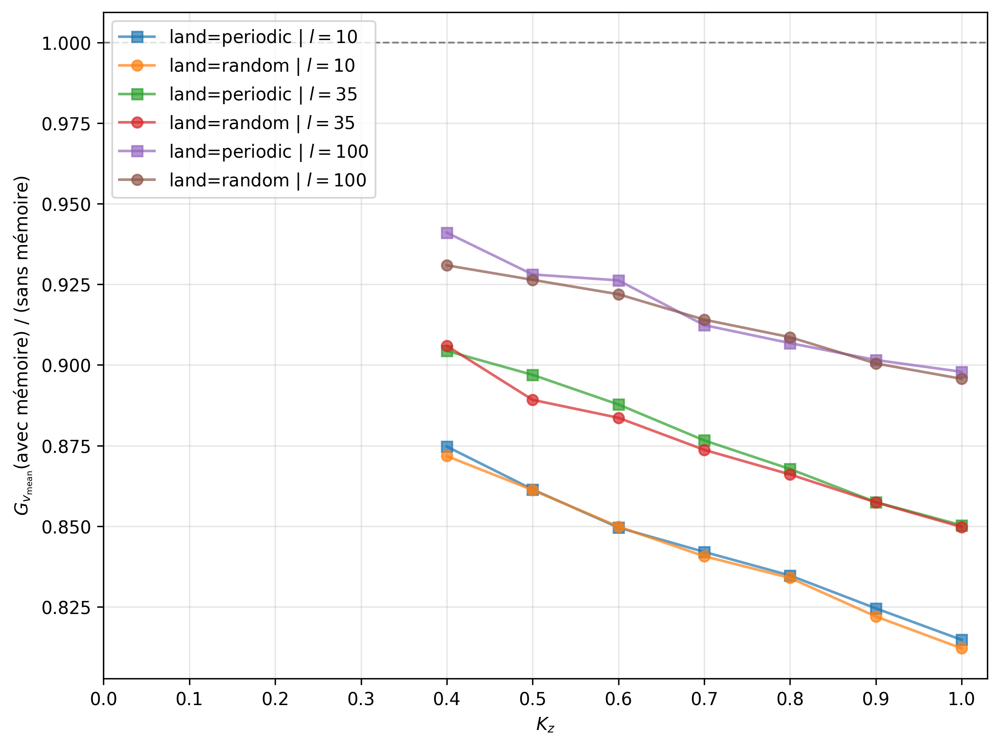

$k_{rel} = 10$ | $K_p = 0.1$ | $\alpha_r = 1$


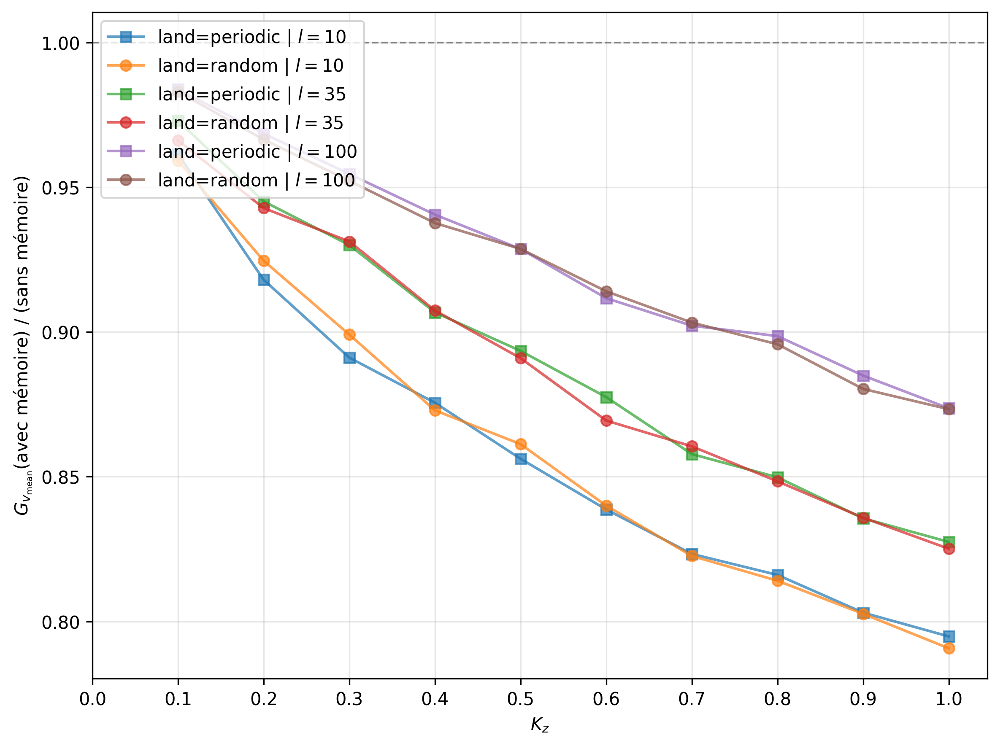

$k_{rel} = 10$ | $K_p = 0.178$ | $\alpha_r = 1$


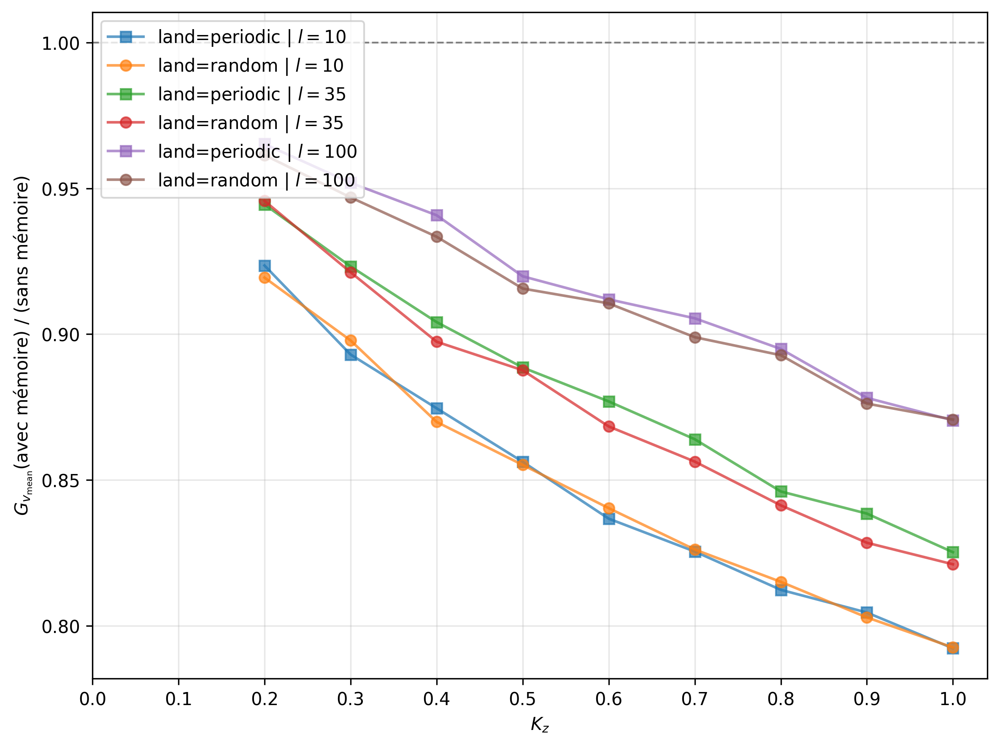

$k_{rel} = 10$ | $K_p = 0.316$ | $\alpha_r = 1$


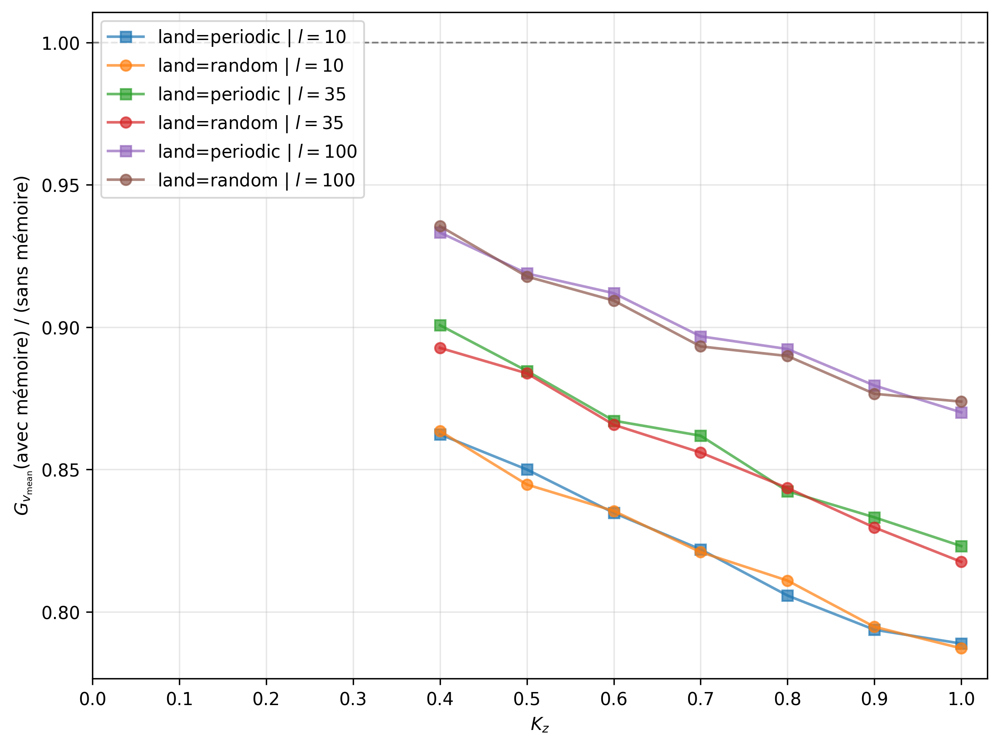

In [29]:
# - Paramètres -----
V_COL = "vc_mean"           # "vc_mean" pour la version bp

# - Données -----
df_actifull = load_actifull()         # référence : sans mémoire
df_actimemo = load_actimemo()         # cas étudié : avec mémoire (alphar = ALPHAR_ACTIVE)

# krel : joint s'il existe des valeurs communes aux deux cas (une seule ligne de référence
# par condition -> une seule courbe par (land, l)). Sinon on ne le joint pas et on compare
# à chaque krel_ref disponible.
krel_memo    = {round(x, 6) for x in df_actimemo["krel"].unique().to_list()}
krel_actifull = {round(x, 6) for x in df_actifull["krel"].unique().to_list()}

EXCLUDE  = () if (krel_memo & krel_actifull) else ("krel",)
KREL_COL = "krel_ref" if EXCLUDE else "krel"

print("Paramètres qui diffèrent entre actif avec mémoire et actif sans mémoire :")
report_overlap(df_actimemo, df_actifull, exclude=EXCLUDE)

# - Gain G = v(actif avec mémoire) / v(actif sans mémoire) -----
g = compute_gain(df_actimemo, df_actifull, value=V_COL, exclude=EXCLUDE)
print()
print(g.select(["land", "l", "alphar", "krel", "Kp", "Kz", "v_num", "v_ref", "gain"]).head(10))

# - Plots : une figure par (krel, Kp), alphar = ALPHAR_ACTIVE -----
for krel in sorted(g[KREL_COL].unique().to_list()):
    for Kp in sorted(g["Kp"].unique().to_list()):

        sub = keep_kz_ge_kp(sel(g, alphar=ALPHAR_ACTIVE, Kp=Kp, **{KREL_COL: krel}))

        title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$ | $\alpha_r = {ALPHAR_ACTIVE:g}$"
        print(title)
        plot_curves(
            sub, x="Kz", y="gain",
            xlabel=r"$K_z$", ylabel=r"$G_{v_{\mathrm{mean}}}$(avec mémoire) / (sans mémoire)",
            # title=rf"$k_{{rel}} = {krel:.3g}$ | $K_p = {Kp:.3g}$ | $\alpha_r = {ALPHAR_ACTIVE:g}$",
            xticks=np.arange(0, 1.1, 0.10), yticks=None, ylim=None, hline=1,
            legend_loc="upper left",
        )


# 4. Identification du mode de remodelage

In [ ]:
root_passmemo = ROOT_PASSIVE = f"{OUTPUTS}/FACT__PSMN__2026"
root_actifull = ROOT_ACTIVE  = f"{OUTPUTS}/FACT__PSMN__2026-09-26"   
root_actimemo = ROOT_ACTIVE  = f"{OUTPUTS}/FACT__PSMN__2026-09-26"   

from nucleo.io.reading import finding_one_parquet

In [17]:
dfs = [
    df_passive,
    df_actifull,
    df_actimemo,
]

all_columns = set().union(*(df.columns for df in dfs))

dfs = [
    df.with_columns(
        [
            pl.lit(float("nan")).alias(col)
            for col in all_columns
            if col not in df.columns
        ]
    )
    for df in dfs
]

df_fact = pl.concat(dfs, how="diagonal")

print(df_fact)


tol = 1e-2

df_same_vc = (
    df_fact
    .with_columns(
        (pl.col("vc_mean") / tol).round().alias("vc_bin")
    )
    .group_by("vc_bin")
    .agg(
        pl.col("mode").n_unique().alias("n_modes")
    )
    .filter(pl.col("n_modes") > 1)
    .join(
        df_fact.with_columns(
            (pl.col("vc_mean") / tol).round().alias("vc_bin")
        ),
        on="vc_bin",
        how="left"
    )
    .sort("vc_mean")
    .drop("vc_bin")
)

print(df_same_vc.columns)

shape: (2_310, 62)
┌──────┬──────┬──────────┬───────┬───┬──────────┬──────────┬───────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dt_mean  ┆ dt_med   ┆ dt_mp ┆ Kpalphar │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---   ┆ ---      │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64      ┆ f64      ┆ f64   ┆ f64      │
╞══════╪══════╪══════════╪═══════╪═══╪══════════╪══════════╪═══════╪══════════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.99868  ┆ 0.83776  ┆ 0.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.997261 ┆ 0.835628 ┆ 0.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.998401 ┆ 0.837547 ┆ 0.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.997886 ┆ 0.837473 ┆ 0.5   ┆ 0.0      │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 0.998388 ┆ 0.835888 ┆ 0.5   ┆ 0.0      │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …        ┆ …        ┆ …     ┆ …        │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 1.003366 ┆ 0.843056 ┆ 0.5   ┆ NaN      │
│ 2S   ┆ true ┆ actim

# .